# 1: Ecological Baseline

## Research Question

Can population density dynamics emerge in the absence of evolution?

This notebook establishes the ecological baseline for the entire project.

No phenotype.
No genetics.
No eco-evolutionary feedback.

Only population abundance is modelled.

---

## State Variable

Population abundance:

$$
N_t
$$

---

## Ecological Model

Discrete logistic growth:

$$
N_{t+1}
=
N_t
+
rN_t
\left(
1-\frac{N_t}{K}
\right)
$$

where

- \(N_t\) = population size at time t
- \(r\) = intrinsic growth rate
- \(K\) = carrying capacity

---

## Objectives

1. Simulate logistic growth
2. Explore parameter space
3. Visualise trajectories
4. Build phase plots
5. Characterise equilibrium behaviour

---

## Why this notebook matters

Later notebooks introduce:

- phenotype
- plasticity
- genetics
- eco-evolutionary feedback

To detect eco-evolutionary feedback statistically, we must first understand what ecological dynamics alone can generate.

In [1]:
# Check Python environment

import sys

print("Python version:")
print(sys.version)

Python version:
3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [2]:
# Required libraries

libraries = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scipy",
    "pymc",
    "arviz",
    "ipywidgets"
    
]

## conda install gxx    to accelerate model

for lib in libraries:
    try:
        __import__(lib)
        print(f"{lib}: OK")
    except ImportError:
        print(f"{lib}: MISSING")

numpy: OK
pandas: OK
matplotlib: OK
seaborn: OK
scipy: OK


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import fsolve

sns.set_theme(style="whitegrid")

# Logistic Growth Function

The logistic model assumes:

1. Population grows exponentially when rare.
2. Growth slows due to competition.
3. Population converges toward carrying capacity.

Mechanistically:

$$
rN_t
$$

represents reproduction.

$$
1-\frac{N_t}{K}
$$

represents density dependence.

In [4]:
def logistic_growth(
    N0,
    r,
    K,
    generations
):
    
    N = np.zeros(generations)
    
    N[0] = N0
    
    for t in range(generations-1):
        
        N[t+1] = (
            N[t]
            +
            r*N[t]*
            (1-N[t]/K)
        )
        
    return N

In [5]:
# Baseline parameters

N0 = 20

r = 0.4

K = 100

generations = 100

N = logistic_growth(
    N0,
    r,
    K,
    generations
)

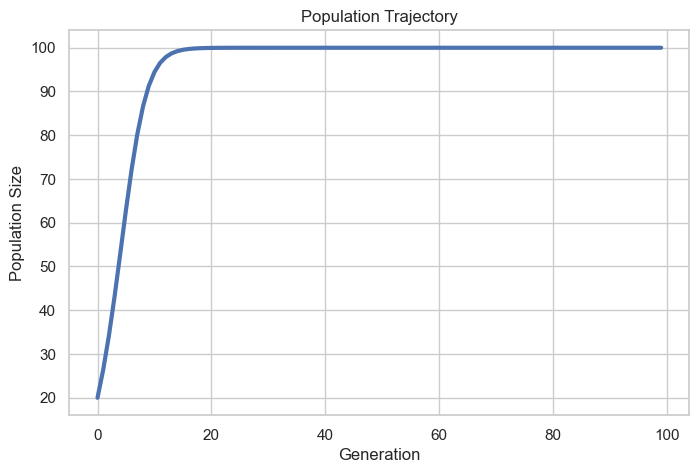

In [6]:
fig, ax = plt.subplots(
    figsize=(8,5)
)

ax.plot(
    N,
    linewidth=3
)

ax.set_title(
    "Population Trajectory"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Population Size"
)

plt.show()

### Interpretation

The population converges toward a stable equilibrium.

The equilibrium occurs near:

$$
N^*=K
$$

This behaviour emerges without any evolutionary process.

This is the ecological null expectation.

# Exploring Growth Rate

Question:

How does intrinsic growth rate influence dynamics?

We compare:

$$
r=
0.1,
0.5,
1.0,
2.0
$$

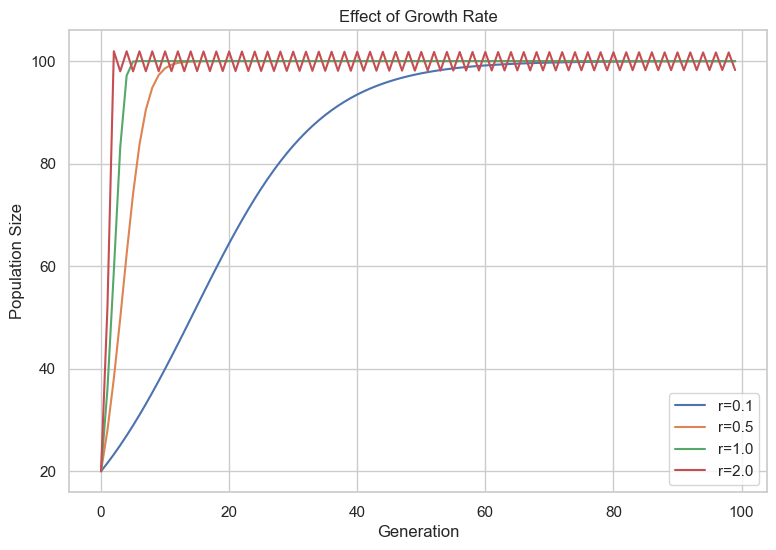

In [8]:
r_values = [0.1,0.5,1.0,2.0]

fig, ax = plt.subplots(
    figsize=(9,6)
)

for r in r_values:
    
    N = logistic_growth(
        N0=20,
        r=r,
        K=100,
        generations=100
    )
    
    ax.plot(
        N,
        label=f"r={r}"
    )

ax.legend()

ax.set_title(
    "Effect of Growth Rate"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Population Size"
)

plt.show()

### Interpretation

Larger values of \(r\):

- increase recovery speed
- increase overshoot
- can generate oscillatory behaviour

This is important because later eco-evolutionary dynamics may be confused with purely ecological oscillations.

In [9]:
# Parameter grid

r_grid = np.linspace(
    0.1,
    2.5,
    40
)

K_grid = np.linspace(
    50,
    300,
    40
)

final_density = np.zeros(
    (len(r_grid),
     len(K_grid))
)

In [10]:
for i,r in enumerate(r_grid):
    
    for j,K in enumerate(K_grid):
        
        N = logistic_growth(
            N0=20,
            r=r,
            K=K,
            generations=200
        )
        
        final_density[i,j] = N[-1]

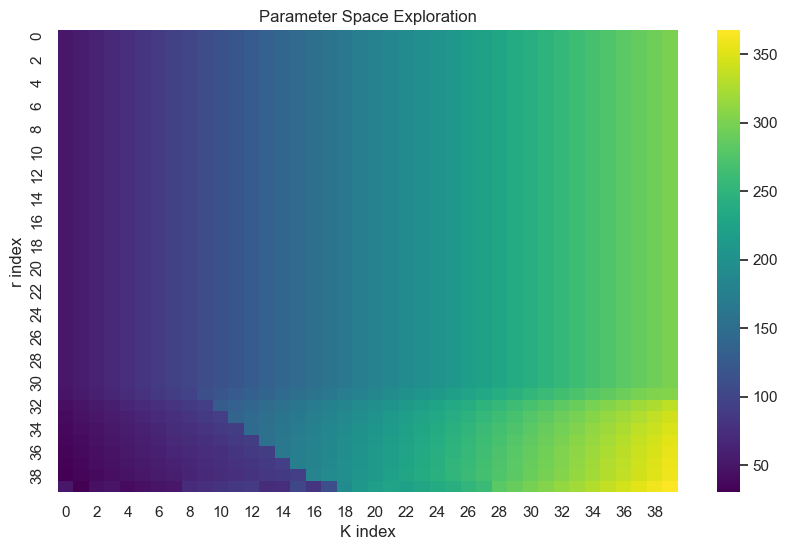

In [12]:
plt.figure(
    figsize=(10,6)
)

sns.heatmap(
    final_density,
    cmap="viridis"
)

plt.title(
    "Parameter Space Exploration"
)

plt.xlabel(
    "K index"
)

plt.ylabel(
    "r index"
)

plt.show()

### Interpretation

The heatmap shows equilibrium density across ecological parameter space.

This establishes the range of dynamics that can arise before introducing phenotype or evolution.

# Phase Plot

A phase plot visualises:

$$
N_t
$$

versus

$$
N_{t+1}
$$

instead of time.

Fixed points occur where:

$$
N_{t+1}=N_t
$$

These intersections correspond to equilibria.

In [13]:
N = logistic_growth(
    N0=20,
    r=1.2,
    K=100,
    generations=100
)

Nt = N[:-1]
Nt1 = N[1:]

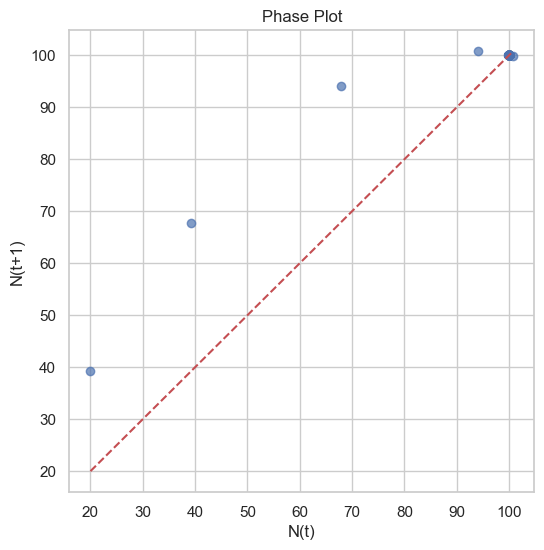

In [15]:
fig, ax = plt.subplots(
    figsize=(6,6)
)

ax.scatter(
    Nt,
    Nt1,
    alpha=0.7
)

lims = [
    min(min(Nt),min(Nt1)),
    max(max(Nt),max(Nt1))
]

ax.plot(
    lims,
    lims,
    'r--'
)

ax.set_xlabel(
    "N(t)"
)

ax.set_ylabel(
    "N(t+1)"
)

ax.set_title(
    "Phase Plot"
)

plt.show()

### Interpretation

The dashed line represents:

$$
N_{t+1}=N_t
$$

The intersection defines the equilibrium.

Phase plots are useful because later notebooks will extend the state space from:

$$
N
$$

to

$$
(N,z)
$$

and eventually

$$
(N,z,G)
$$

allowing direct visualisation of eco-evolutionary feedbacks.

# Fixed Point Analysis

Equilibrium occurs when:

$$
N_{t+1}=N_t
$$

Substituting the logistic model:

$$
N_t
=
N_t+rN_t\left(1-\frac{N_t}{K}\right)
$$

which yields:

$$
N^*=0
$$

and

$$
N^*=K
$$

These are the ecological attractors of the system.

In [16]:
print("Fixed point 1: N*=0")
print(f"Fixed point 2: N*={K}")

Fixed point 1: N*=0
Fixed point 2: N*=300.0


# 2. Trait-dependent Ecology

Can phenotype influence population dynamics?

## Research Question

Can phenotype affect population abundance dynamics?

In Notebook 1 we assumed:

$$
K = constant
$$

Now we assume:

$$
K(z)
=
K_0(1+\alpha z)
$$

where:

- \(z\) = mean phenotype
- \(K_0\) = baseline carrying capacity
- \(\alpha\) = trait effect

---

## Biological Interpretation

Large body size may:

- improve resource acquisition
- improve competitive ability
- increase habitat use

leading to larger carrying capacity.

---

## Objectives

1. Introduce phenotype
2. Create trait-dependent carrying capacity
3. Compare small and large phenotypes
4. Quantify demographic consequences
5. Establish Trait → Ecology linkage

---

## Contribution to Main Project

This notebook introduces the first mechanistic pathway:

\[
Trait
\rightarrow
Ecology
\]

which later becomes part of the eco-evolutionary feedback loop.

In [17]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Trait-dependent Carrying Capacity

We define:

$$
K(z)
=
K_0(1+\alpha z)
$$

where

$$
\alpha>0
$$

means larger individuals support larger populations.

This creates a phenotype-dependent ecological system.

In [36]:
def carrying_capacity(
    z,
    K0,
    alpha
):
    
    return K0*np.exp(alpha*z)

In [37]:
def simulate_population(
    N0,
    z,
    r,
    K0,
    alpha,
    generations
):
    
    K = carrying_capacity(
        z,
        K0,
        alpha
    )
    
    N = np.zeros(generations)
    
    N[0] = N0
    
    for t in range(generations-1):
        
        N[t+1] = (
            N[t]
            +
            r*N[t]*
            (1-N[t]/K)
        )
        
    return N

In [20]:
# baseline parameters

N0 = 20

r = 0.4

K0 = 100

alpha = 0.5

generations = 100

# Small versus Large Phenotypes

We compare:

Small phenotype:

$$
z=-1
$$

Average phenotype:

$$
z=0
$$

Large phenotype:

$$
z=1
$$

The only difference between simulations is phenotype.

In [38]:
z_values = [-1,0,1]

results = {}

for z in z_values:
    
    N = simulate_population(
        N0=N0,
        z=z,
        r=r,
        K0=K0,
        alpha=alpha,
        generations=generations
    )
    
    results[z] = N

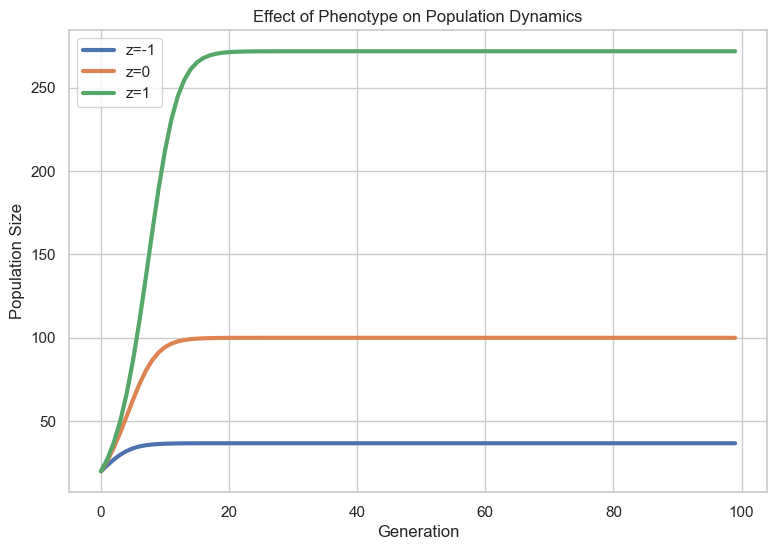

In [39]:
fig, ax = plt.subplots(
    figsize=(9,6)
)

for z,N in results.items():
    
    ax.plot(
        N,
        linewidth=3,
        label=f"z={z}"
    )

ax.legend()

ax.set_title(
    "Effect of Phenotype on Population Dynamics"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Population Size"
)

plt.show()

### Interpretation

Larger phenotypes generate larger equilibrium populations.

The mechanism is:

$$
z
\rightarrow
K(z)
\rightarrow
N
$$

No feedback exists yet.

Phenotype influences ecology, but ecology does not influence phenotype.

In [40]:
trait_range = np.linspace(
    -2,
    2,
    100
)

K_values = carrying_capacity(
    trait_range,
    K0,
    alpha
)

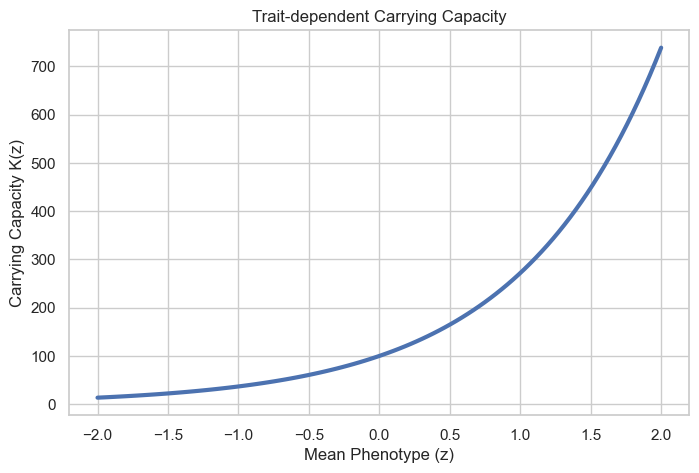

In [41]:
fig, ax = plt.subplots(
    figsize=(8,5)
)

ax.plot(
    trait_range,
    K_values,
    linewidth=3
)

ax.set_title(
    "Trait-dependent Carrying Capacity"
)

ax.set_xlabel(
    "Mean Phenotype (z)"
)

ax.set_ylabel(
    "Carrying Capacity K(z)"
)

plt.show()

### Interpretation

The slope:

$$
\frac{dK}{dz}
=
K_0\alpha
$$

measures ecological sensitivity to phenotype.

Larger values indicate stronger trait effects.

In [42]:
alpha_values = [
    0,
    0.25,
    0.5,
    1.0
]

z = 1

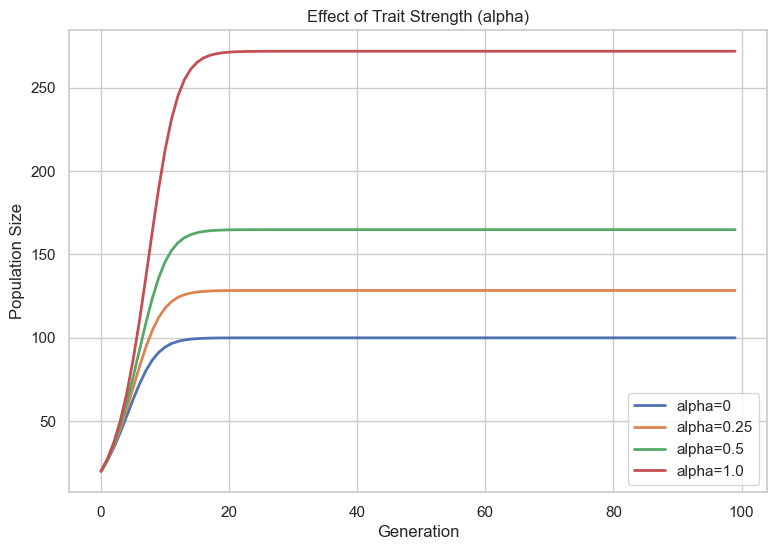

In [43]:
fig, ax = plt.subplots(
    figsize=(9,6)
)

for alpha in alpha_values:
    
    N = simulate_population(
        N0,
        z,
        r,
        K0,
        alpha,
        generations
    )
    
    ax.plot(
        N,
        linewidth=2,
        label=f"alpha={alpha}"
    )

ax.legend()

ax.set_title(
    "Effect of Trait Strength (alpha)"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Population Size"
)

plt.show()

### Interpretation

$$
\alpha
$$

controls the strength of trait effects on ecology.

Later notebooks will estimate this parameter statistically.

Therefore this simulation provides the "ground truth".

In [44]:
final_sizes = []

for z in trait_range:
    
    N = simulate_population(
        N0,
        z,
        r,
        K0,
        alpha=0.5,
        generations=200
    )
    
    final_sizes.append(
        N[-1]
    )

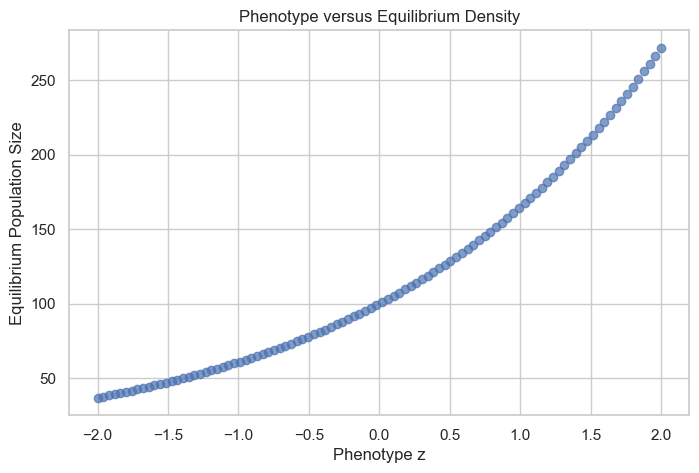

In [45]:
fig, ax = plt.subplots(
    figsize=(8,5)
)

ax.scatter(
    trait_range,
    final_sizes,
    alpha=0.7
)

ax.set_title(
    "Phenotype versus Equilibrium Density"
)

ax.set_xlabel(
    "Phenotype z"
)

ax.set_ylabel(
    "Equilibrium Population Size"
)

plt.show()

### Interpretation

This figure quantifies the ecological consequence of phenotype.

Equilibrium density increases approximately linearly with phenotype because:

$$
N^*
=
K(z)
$$

under logistic growth.

In [46]:
growth_rates = []

for z in trait_range:
    
    K = carrying_capacity(
        z,
        K0,
        0.5
    )
    
    initial_growth = (
        r*N0*(1-N0/K)
    )
    
    growth_rates.append(
        initial_growth
    )

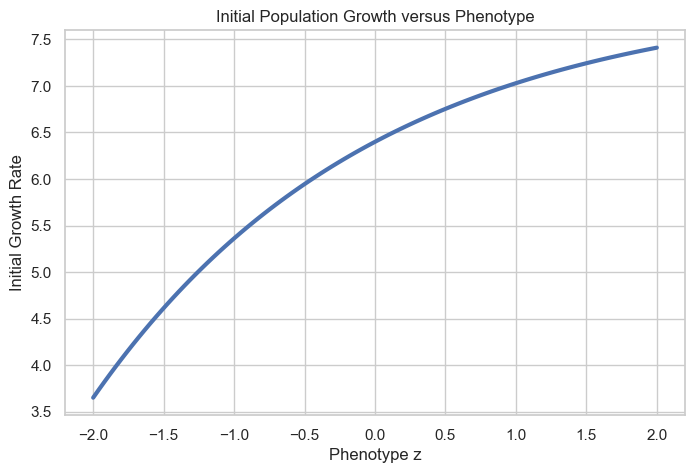

In [47]:
fig, ax = plt.subplots(
    figsize=(8,5)
)

ax.plot(
    trait_range,
    growth_rates,
    linewidth=3
)

ax.set_title(
    "Initial Population Growth versus Phenotype"
)

ax.set_xlabel(
    "Phenotype z"
)

ax.set_ylabel(
    "Initial Growth Rate"
)

plt.show()

### Interpretation

Phenotype affects:

1. equilibrium density

2. transient dynamics

3. population recovery

This is important because later Bayesian models may infer trait effects from these demographic signatures.


# Statistical Relevance

Suppose we observe:

$$
N_t
$$

but not phenotype.

Variation in abundance could originate from:

- ecological parameters
- environmental forcing
- phenotype

This creates an inference challenge.

Later notebooks ask:

Can we distinguish these possibilities statistically?

In [48]:
df = pd.DataFrame({
    "generation": np.arange(generations),
    "N": results[1],
    "z": 1
})

df.to_csv(
    "trait_ecology_example.csv",
    index=False
)

## 3.  Ecology-to-Trait Feedback

In Notebook 2:

$$
z
\rightarrow
N
$$

Phenotype affected ecology.

Now we introduce:

$$
N
\rightarrow
z
$$

creating a feedback loop.

---

## Ecological Feedback Model

Carrying capacity:

$$
K(z)
=
K_0 e^{\alpha z}
$$

Population dynamics:

$$
N_{t+1}
=
N_t
+
rN_t
\left(
1-\frac{N_t}{K(z_t)}
\right)
$$

Trait dynamics:

$$
z_{t+1}
=
z_t
-
\beta N_t
$$


where:

- \(N_t\) = abundance
- \(z_t\) = phenotype
- \(\\beta\) = competition effect

---

## Interpretation

High density:

$$
N_t \uparrow
$$

reduces body size:

$$
z_t \downarrow
$$

Smaller body size reduces carrying capacity:

$$
K(z)\downarrow
$$

which feeds back on abundance.

---

## Goal

Build the first eco-phenotypic feedback system.

In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Model Functions

In [50]:
def carrying_capacity(
    z,
    K0,
    alpha
):
    
    return K0*np.exp(alpha*z)

In [51]:
def eco_trait_model(
    N0,
    z0,
    r,
    K0,
    alpha,
    beta,
    generations
):
    
    N = np.zeros(generations)
    z = np.zeros(generations)
    
    N[0] = N0
    z[0] = z0
    
    for t in range(generations-1):
        
        K = carrying_capacity(
            z[t],
            K0,
            alpha
        )
        
        N[t+1] = (
            N[t]
            +
            r*N[t]*
            (
                1-N[t]/K
            )
        )
        
        N[t+1] = max(
            N[t+1],
            0.01
        )
        
        z[t+1] = (
            z[t]
            -
            beta*N[t]
        )
    
    return N,z

### Baseline Simulation

In [52]:
N,z = eco_trait_model(
    N0=20,
    z0=1.0,
    r=0.4,
    K0=100,
    alpha=0.3,
    beta=0.001,
    generations=200
)

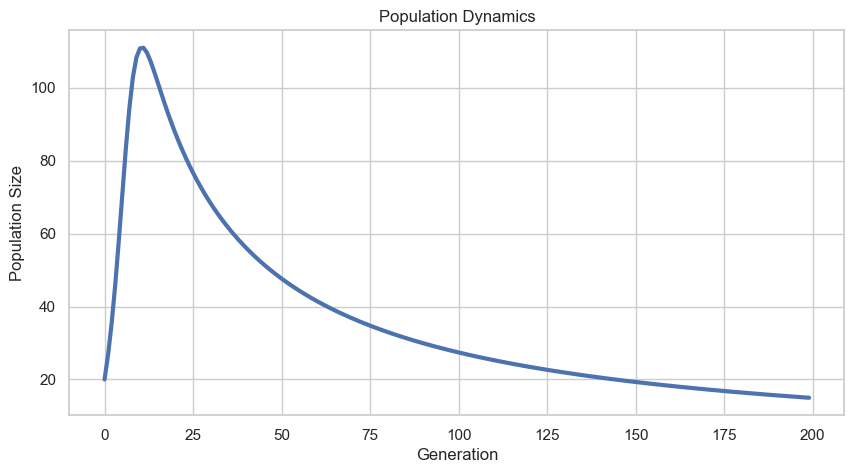

In [53]:
fig,ax = plt.subplots(
    figsize=(10,5)
)

ax.plot(
    N,
    linewidth=3
)

ax.set_title(
    "Population Dynamics"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Population Size"
)

plt.show()

### Interpretation

Population abundance initially increases.

As density rises:

$$
N_t
$$

competition increases.

This begins to affect phenotype.

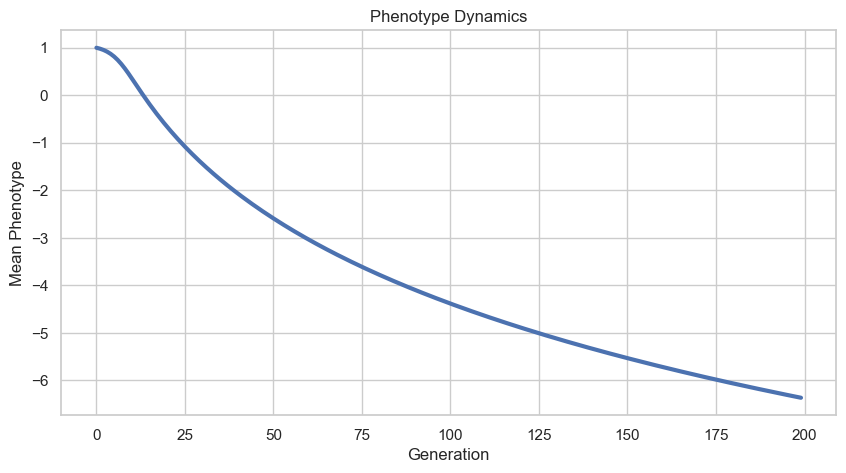

In [55]:
fig,ax = plt.subplots(
    figsize=(10,5)
)

ax.plot(
    z,
    linewidth=3
)

ax.set_title(
    "Phenotype Dynamics"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Mean Phenotype"
)

plt.show()

### Interpretation

Phenotype declines because:

$$
z_{t+1}
=
z_t-\beta N_t
$$

Higher abundance causes stronger competitive effects.

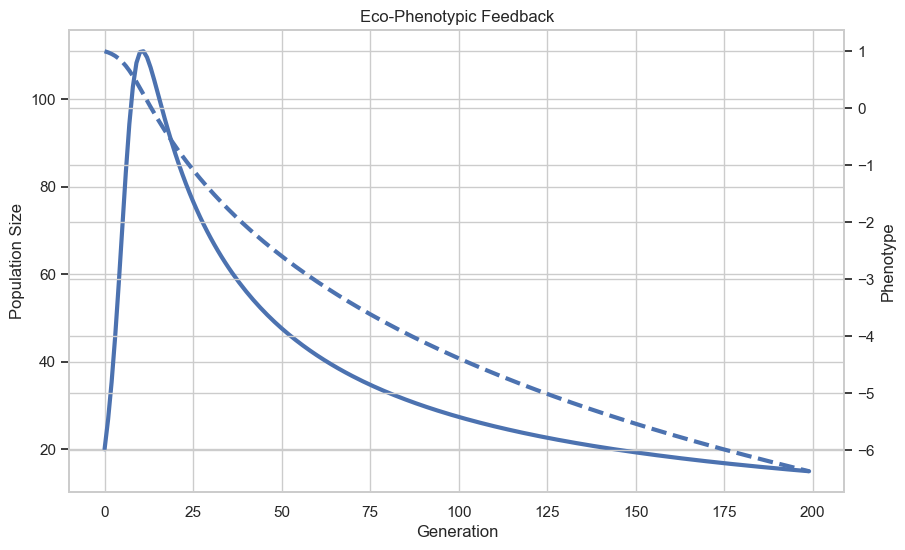

In [56]:
fig,ax = plt.subplots(
    figsize=(10,6)
)

ax.plot(
    N,
    label="N(t)",
    linewidth=3
)

ax2 = ax.twinx()

ax2.plot(
    z,
    linestyle="--",
    linewidth=3,
    label="z(t)"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Population Size"
)

ax2.set_ylabel(
    "Phenotype"
)

plt.title(
    "Eco-Phenotypic Feedback"
)

plt.show()

### Interpretation

This figure visualises the feedback loop directly.

Phenotype influences ecology.

Ecology influences phenotype.

The system is now bidirectional.

### Phase Portrait

State space:

$$
(N,z)
$$

Each point represents the system state.

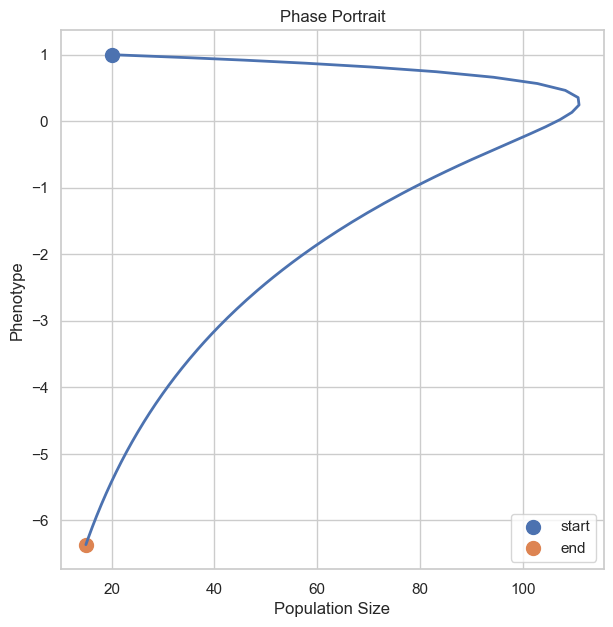

In [57]:
fig,ax = plt.subplots(
    figsize=(7,7)
)

ax.plot(
    N,
    z,
    linewidth=2
)

ax.scatter(
    N[0],
    z[0],
    s=100,
    label="start"
)

ax.scatter(
    N[-1],
    z[-1],
    s=100,
    label="end"
)

ax.legend()

ax.set_xlabel(
    "Population Size"
)

ax.set_ylabel(
    "Phenotype"
)

ax.set_title(
    "Phase Portrait"
)

plt.show()

### Interpretation

The trajectory moves through state space.

This is the first dynamical-system representation of the eco-phenotypic model.

Later sections will estimate these trajectories from noisy observations.

In [58]:
beta_values = [
    0.0,
    0.0005,
    0.001,
    0.002
]

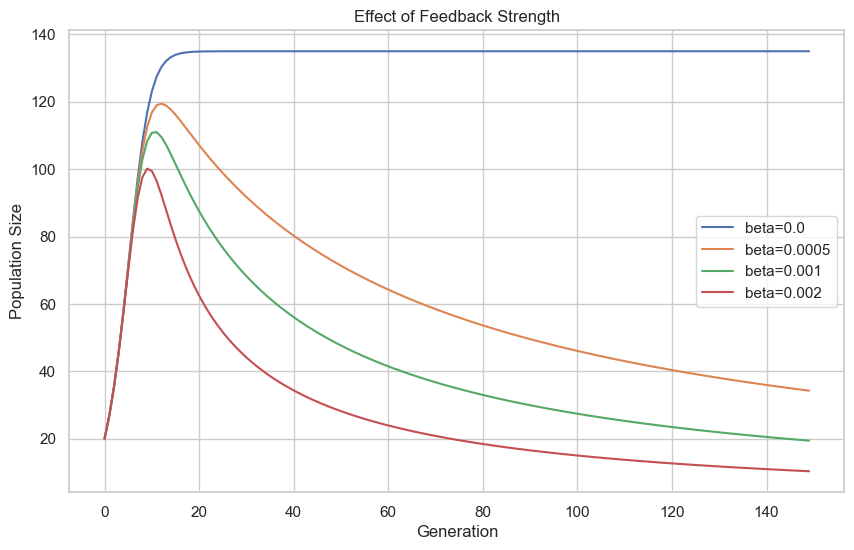

In [59]:
fig,ax = plt.subplots(
    figsize=(10,6)
)

for beta in beta_values:
    
    N,z = eco_trait_model(
        N0=20,
        z0=1,
        r=0.4,
        K0=100,
        alpha=0.3,
        beta=beta,
        generations=150
    )
    
    ax.plot(
        N,
        label=f"beta={beta}"
    )

ax.legend()

ax.set_title(
    "Effect of Feedback Strength"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Population Size"
)

plt.show()

### Interpretation

$$
\beta
$$

controls feedback strength.

When:

$$
\beta=0
$$

the model reduces to Section 2.

Increasing feedback strength alters population trajectories.

In [60]:
final_N = []
final_z = []

for beta in np.linspace(
    0,
    0.003,
    50
):
    
    N,z = eco_trait_model(
        20,
        1,
        0.4,
        100,
        0.3,
        beta,
        300
    )
    
    final_N.append(
        N[-1]
    )
    
    final_z.append(
        z[-1]
    )

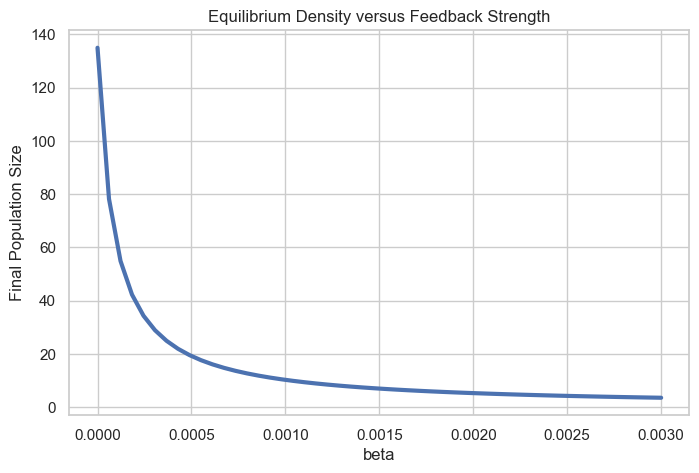

In [61]:
fig,ax = plt.subplots(
    figsize=(8,5)
)

ax.plot(
    np.linspace(0,0.003,50),
    final_N,
    linewidth=3
)

ax.set_title(
    "Equilibrium Density versus Feedback Strength"
)

ax.set_xlabel(
    "beta"
)

ax.set_ylabel(
    "Final Population Size"
)

plt.show()

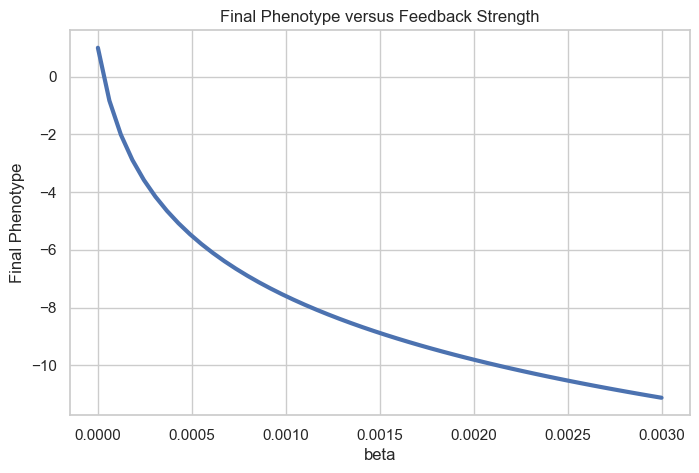

In [62]:
fig,ax = plt.subplots(
    figsize=(8,5)
)

ax.plot(
    np.linspace(0,0.003,50),
    final_z,
    linewidth=3
)

ax.set_title(
    "Final Phenotype versus Feedback Strength"
)

ax.set_xlabel(
    "beta"
)

ax.set_ylabel(
    "Final Phenotype"
)

plt.show()

# Quantifying Feedback

A simple diagnostic is:

$$
corr(N_t,z_t)
$$

Strong feedback should create stronger coupling between abundance and phenotype.

In [63]:
correlation = np.corrcoef(
    N,
    z
)[0,1]

print(
    "Correlation:",
    correlation
)

Correlation: 0.8773404839003028


### Interpretation

The correlation is not a causal estimate.

However it provides a first quantitative signature of coupling between ecology and phenotype.

In [64]:
df = pd.DataFrame({
    "generation":np.arange(len(N)),
    "N":N,
    "z":z
})

df.to_csv(
    "eco_trait_feedback.csv",
    index=False
)

print(
    "saved: eco_trait_feedback.csv"
)

saved: eco_trait_feedback.csv


In [65]:
print(df.describe())

       generation           N           z
count  300.000000  300.000000  300.000000
mean   149.500000   13.484731   -8.060418
std     86.746758   16.652846    2.818220
min      0.000000    3.580821  -11.125516
25%     74.750000    4.734126  -10.203538
50%    149.500000    6.998207   -8.917813
75%    224.250000   13.547895   -6.765777
max    299.000000   92.398471    1.000000


## 4. Eco-evolutionary Feedback

This section introduces genetic evolution.

State variables:

Population abundance:

$$
N_t
$$

Breeding value:

$$
G_t
$$

Phenotype:

$$
z_t
$$

---

### Phenotype

Phenotype is determined by genetics and environment:

$$
z_t = G_t + E_t
$$

where

$$
E_t \sim N(0,\sigma_E)
$$

---

### Trait-dependent Carrying Capacity

$$
K(z_t)
=
K_0 e^{\alpha z_t}
$$

---

### Population Dynamics

$$
N_{t+1}
=
N_t
+
rN_t
\left(
1-\frac{N_t}{K(z_t)}
\right)
$$

---

### Selection

Selection depends on population density:

$$
S_t
=
-s(N_t-N_{opt})
$$

where

- \(s\) = selection strength
- \(N_{opt}\) = ecological optimum

---

### Evolution

Breeder's equation:

$$
G_{t+1}
=
G_t
+
h^2S_t
$$

where

- \(h^2\) = heritability

---

### Eco-evolutionary Feedback Loop

$$
N_t
\rightarrow
S_t
\rightarrow
G_t
\rightarrow
z_t
\rightarrow
N_t
$$

This is the first true eco-evolutionary feedback system in the project.

In [66]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [67]:
def carrying_capacity(
    z,
    K0,
    alpha
):
    
    return K0*np.exp(alpha*z)

In [68]:
def eco_evo_model(
    N0,
    G0,
    r,
    K0,
    alpha,
    h2,
    s,
    Nopt,
    sigma_E,
    generations
):
    
    N = np.zeros(generations)
    G = np.zeros(generations)
    z = np.zeros(generations)
    
    N[0] = N0
    G[0] = G0
    
    z[0] = (
        G0
        +
        np.random.normal(
            0,
            sigma_E
        )
    )
    
    for t in range(
        generations-1
    ):
        
        K = carrying_capacity(
            z[t],
            K0,
            alpha
        )
        
        N[t+1] = (
            N[t]
            +
            r*N[t]*
            (
                1-N[t]/K
            )
        )
        
        N[t+1] = max(
            N[t+1],
            0.01
        )
        
        S = (
            -s*
            (
                N[t]
                -
                Nopt
            )
        )
        
        G[t+1] = (
            G[t]
            +
            h2*S
        )
        
        z[t+1] = (
            G[t+1]
            +
            np.random.normal(
                0,
                sigma_E
            )
        )
    
    return N,G,z

In [69]:
N,G,z = eco_evo_model(
    N0=20,
    G0=1,
    r=0.4,
    K0=100,
    alpha=0.2,
    h2=0.4,
    s=0.01,
    Nopt=80,
    sigma_E=0.1,
    generations=200
)

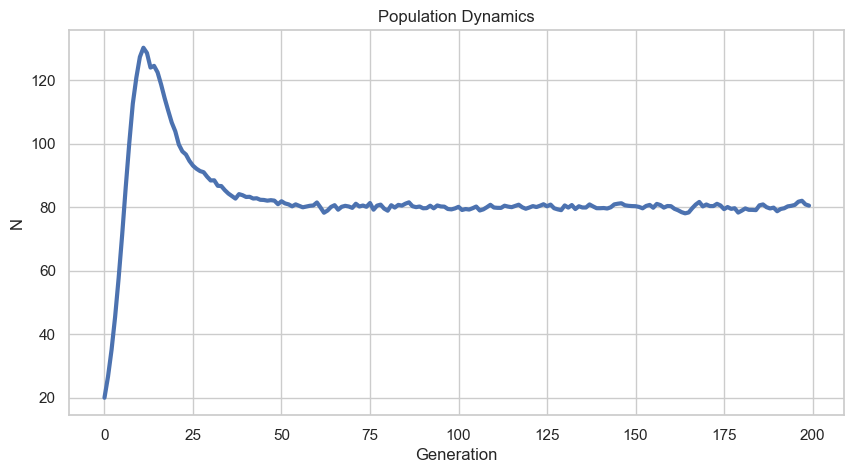

In [70]:
plt.figure(figsize=(10,5))
plt.plot(N,lw=3)
plt.title("Population Dynamics")
plt.xlabel("Generation")
plt.ylabel("N")
plt.show()

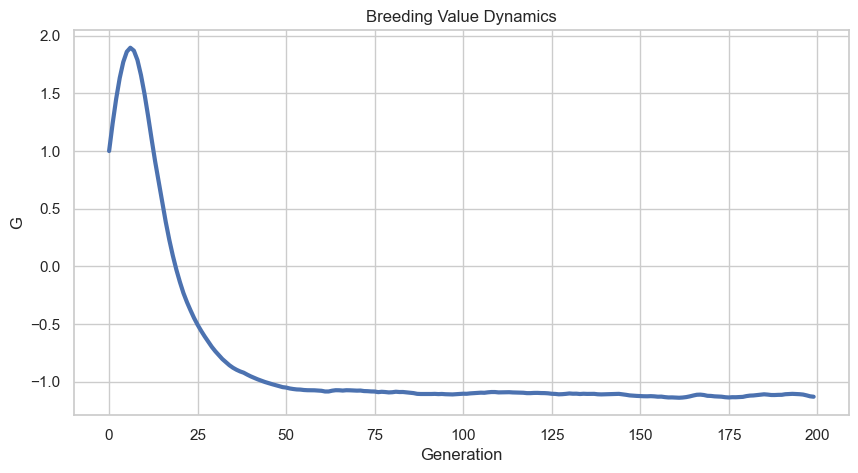

In [71]:
plt.figure(figsize=(10,5))
plt.plot(G,lw=3)
plt.title("Breeding Value Dynamics")
plt.xlabel("Generation")
plt.ylabel("G")
plt.show()

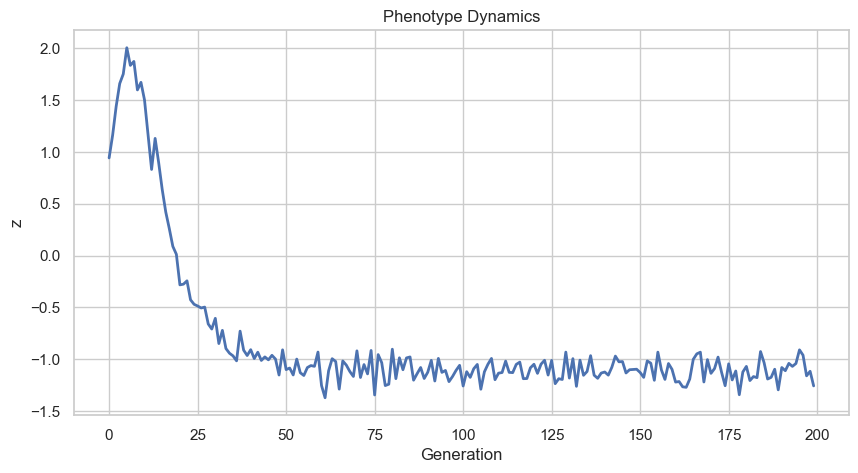

In [72]:
plt.figure(figsize=(10,5))
plt.plot(z,lw=2)
plt.title("Phenotype Dynamics")
plt.xlabel("Generation")
plt.ylabel("z")
plt.show()

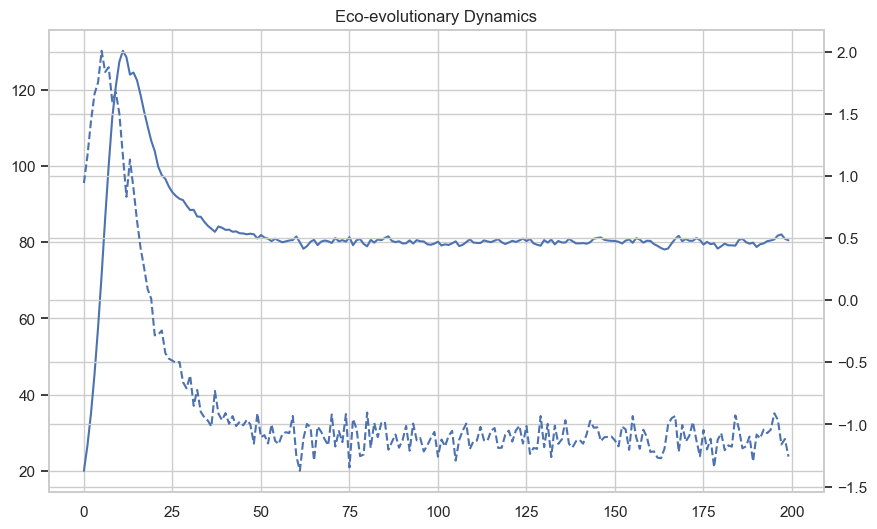

In [73]:
fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.plot(
    N,
    label="N"
)

ax2=ax.twinx()

ax2.plot(
    z,
    "--",
    label="z"
)

plt.title(
    "Eco-evolutionary Dynamics"
)

plt.show()

In [74]:
df = pd.DataFrame({
    "generation":np.arange(len(N)),
    "N":N,
    "G":G,
    "z":z
})

df.to_csv(
    "eco_evolutionary_feedback.csv",
    index=False
)

## 5. Generate Synthetic Datasets

Can different ecological mechanisms generate distinguishable abundance–phenotype time series?

Dataset A --> Environment only (section 2)
Dataset B --> Plasticity (section 3)
Dataset C --> Eco-evol feedback (section 4)

In [75]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

In [76]:
np.random.seed(42)

In [77]:
output_dir = Path(
    "synthetic_datasets"
)

output_dir.mkdir(
    exist_ok=True
)

In [78]:
def simulate_environment_only(
    generations=50
):
    
    T = np.random.normal(
        0,
        1,
        generations
    )
    
    N = np.zeros(generations)
    
    z = np.zeros(generations)
    
    N[0]=100
    
    z[0]=0
    
    for t in range(
        generations-1
    ):
        
        N[t+1] = (
            N[t]
            +
            0.3*(100-N[t])
            +
            5*T[t]
        )
        
        z[t+1] = (
            0.5*T[t]
            +
            np.random.normal(
                0,
                0.2
            )
        )
    
    return N,z,T

In [79]:
def carrying_capacity(
    z,
    K0,
    alpha
):
    
    return K0*np.exp(alpha*z)

In [80]:
def simulate_plasticity(
    generations=50
):
    
    N=np.zeros(generations)
    z=np.zeros(generations)
    
    N[0]=20
    z[0]=1
    
    r=0.4
    K0=100
    alpha=0.3
    beta=0.001
    
    for t in range(
        generations-1
    ):
        
        K=carrying_capacity(
            z[t],
            K0,
            alpha
        )
        
        N[t+1]=(
            N[t]
            +
            r*N[t]*
            (1-N[t]/K)
        )
        
        z[t+1]=(
            z[t]
            -
            beta*N[t]
        )
    
    return N,z

In [81]:
def simulate_eco_evolution(
    generations=50
):
    
    N=np.zeros(generations)
    G=np.zeros(generations)
    z=np.zeros(generations)
    
    N[0]=20
    G[0]=1
    
    r=0.4
    K0=100
    alpha=0.2
    
    h2=0.4
    
    s=0.01
    
    Nopt=80
    
    sigmaE=0.1
    
    z[0]=G[0]
    
    for t in range(
        generations-1
    ):
        
        K=carrying_capacity(
            z[t],
            K0,
            alpha
        )
        
        N[t+1]=(
            N[t]
            +
            r*N[t]*
            (1-N[t]/K)
        )
        
        S=(
            -s*
            (N[t]-Nopt)
        )
        
        G[t+1]=(
            G[t]
            +
            h2*S
        )
        
        z[t+1]=(
            G[t+1]
            +
            np.random.normal(
                0,
                sigmaE
            )
        )
    
    return N,G,z

In [82]:
n_replicates = 100

generations = 50

In [84]:
all_A = []

In [85]:
for rep in range(
    n_replicates
):
    
    N,z,T = simulate_environment_only(
        generations
    )
    
    df = pd.DataFrame({
        "replicate":rep,
        "generation":np.arange(generations),
        "N":N,
        "z":z,
        "T":T,
        "model":"environment"
    })
    
    all_A.append(df)

In [86]:
A = pd.concat(
    all_A,
    ignore_index=True
)

A.to_csv(
    output_dir/
    "dataset_A_environment.csv",
    index=False
)

In [87]:
all_B=[]

In [88]:
for rep in range(
    n_replicates
):
    
    N,z = simulate_plasticity(
        generations
    )
    
    df=pd.DataFrame({
        "replicate":rep,
        "generation":np.arange(generations),
        "N":N,
        "z":z,
        "model":"plasticity"
    })
    
    all_B.append(df)

In [89]:
B=pd.concat(
    all_B,
    ignore_index=True
)

B.to_csv(
    output_dir/
    "dataset_B_plasticity.csv",
    index=False
)

In [90]:
all_C=[]

In [91]:
for rep in range(
    n_replicates
):
    
    N,G,z = simulate_eco_evolution(
        generations
    )
    
    df=pd.DataFrame({
        "replicate":rep,
        "generation":np.arange(generations),
        "N":N,
        "G":G,
        "z":z,
        "model":"eco_evolution"
    })
    
    all_C.append(df)

In [92]:
C=pd.concat(
    all_C,
    ignore_index=True
)

C.to_csv(
    output_dir/
    "dataset_C_eco_evolution.csv",
    index=False
)

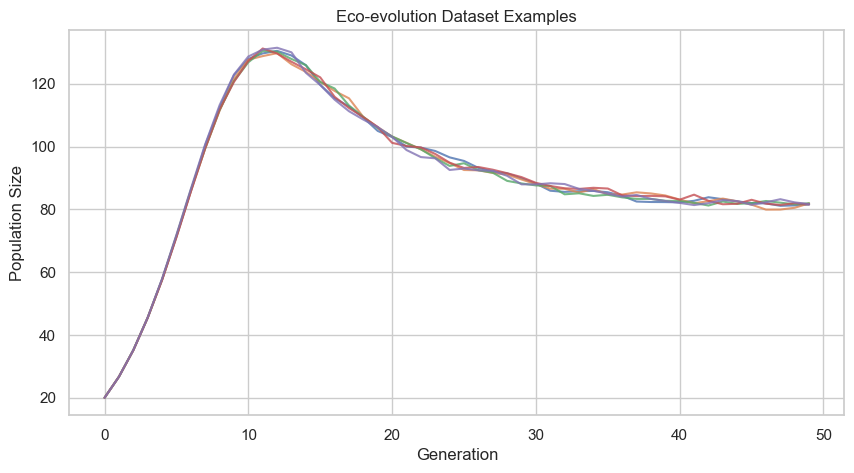

In [93]:
plt.figure(
    figsize=(10,5)
)

for rep in range(5):
    
    subset = C[
        C.replicate==rep
    ]
    
    plt.plot(
        subset.generation,
        subset.N,
        alpha=0.8
    )

plt.title(
    "Eco-evolution Dataset Examples"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Population Size"
)

plt.show()

In [94]:
summary = pd.DataFrame({
    "dataset":[
        "A",
        "B",
        "C"
    ],
    
    "mechanism":[
        "environment",
        "plasticity",
        "eco_evolution"
    ],
    
    "replicates":[
        100,
        100,
        100
    ],
    
    "generations":[
        50,
        50,
        50
    ]
})

summary

,dataset,mechanism,replicates,generations
0,A,environment,100,50
1,B,plasticity,100,50
2,C,eco_evolution,100,50


## 6. Observation Process

Until now we analysed true states:

$$
N_t
$$

$$
z_t
$$

$$
G_t
$$

However real ecologists observe:

$$
N_{obs}
$$

$$
z_{obs}
$$

with error.

---

### Observation Model

State Process

$$
X_t
=
(N_t,z_t,G_t)
$$

Observation Process

$$
Y_t
=
(N_{obs},z_{obs})
$$

---

### Sources of Error

1. Detection error

2. Sampling error

3. Measurement error

4. Missing observations

This notebook creates realistic ecological datasets.

In [95]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

In [96]:
data_dir = Path(
    "synthetic_datasets"
)

output_dir = Path(
    "observed_datasets"
)

output_dir.mkdir(
    exist_ok=True
)

In [97]:
A = pd.read_csv(
    data_dir/
    "dataset_A_environment.csv"
)

B = pd.read_csv(
    data_dir/
    "dataset_B_plasticity.csv"
)

C = pd.read_csv(
    data_dir/
    "dataset_C_eco_evolution.csv"
)

### Detection Error

Observed abundance is only a sample of the true population.

We model counts as:

$$
N_{obs}
\sim
Poisson(pN)
$$

where

$$
p
$$

is detection probability.

In [98]:
def add_detection_error(
    N,
    p=0.6
):
    
    lam = np.maximum(
        p*N,
        0.01
    )
    
    return np.random.poisson(
        lam
    )

### Measurement Error

Observed phenotype contains measurement uncertainty.

$$
z_{obs}
=
z
+
\epsilon
$$

where

$$
\epsilon
\sim
N(0,\sigma)
$$

In [99]:
def add_measurement_error(
    z,
    sigma=0.3
):
    
    return (
        z
        +
        np.random.normal(
            0,
            sigma,
            len(z)
        )
    )

### Missing Data

Field observations are often incomplete.

Some measurements are removed randomly. 

In [109]:
def add_missing_values(
    x,
    proportion=0.1
):
    
    x = x.astype(float).copy()
    
    idx = np.random.choice(
        len(x),
        int(proportion*len(x)),
        replace=False
    )
    
    x[idx] = np.nan
    
    return x

In [110]:
def observe_dataset(
    df,
    detection_p=0.6,
    sigma_z=0.3,
    missing_rate=0.1
):
    
    observed = df.copy()
    
    observed["N_obs"] = (
        add_detection_error(
            observed["N"].values,
            detection_p
        )
    )
    
    observed["z_obs"] = (
        add_measurement_error(
            observed["z"].values,
            sigma_z
        )
    )
    
    observed["N_obs"] = (
        add_missing_values(
            observed["N_obs"].values,
            missing_rate
        )
    )
    
    observed["z_obs"] = (
        add_missing_values(
            observed["z_obs"].values,
            missing_rate
        )
    )
    
    return observed

In [111]:
A_obs = observe_dataset(A)

B_obs = observe_dataset(B)

C_obs = observe_dataset(C)

In [112]:
A_obs.to_csv(
    output_dir/
    "A_observed.csv",
    index=False
)

B_obs.to_csv(
    output_dir/
    "B_observed.csv",
    index=False
)

C_obs.to_csv(
    output_dir/
    "C_observed.csv",
    index=False
)

In [113]:
rep = 0

subset = C_obs[
    C_obs.replicate==rep
]

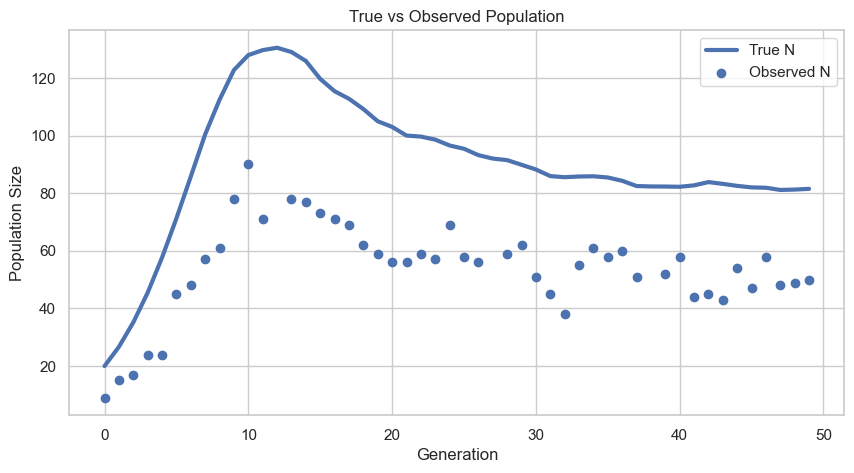

In [114]:
plt.figure(
    figsize=(10,5)
)

plt.plot(
    subset.generation,
    subset.N,
    label="True N",
    linewidth=3
)

plt.scatter(
    subset.generation,
    subset.N_obs,
    label="Observed N"
)

plt.legend()

plt.title(
    "True vs Observed Population"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Population Size"
)

plt.show()

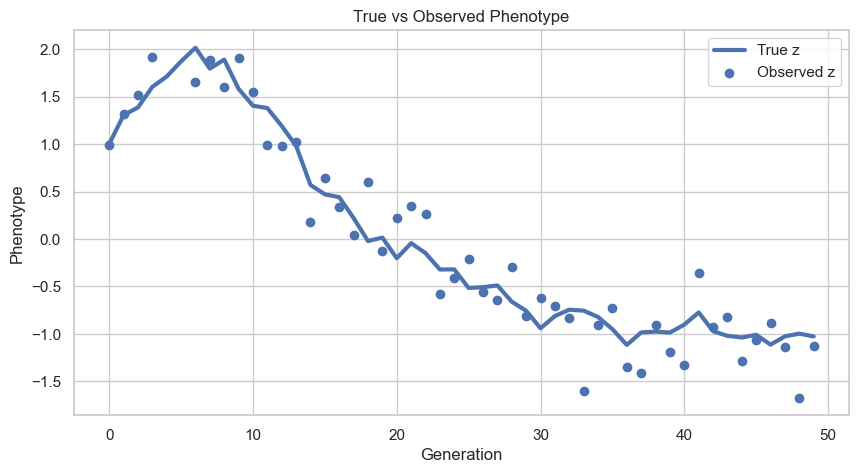

In [115]:
plt.figure(
    figsize=(10,5)
)

plt.plot(
    subset.generation,
    subset.z,
    label="True z",
    linewidth=3
)

plt.scatter(
    subset.generation,
    subset.z_obs,
    label="Observed z"
)

plt.legend()

plt.title(
    "True vs Observed Phenotype"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Phenotype"
)

plt.show()

In [116]:
summary = pd.DataFrame({
    
    "dataset":[
        "A",
        "B",
        "C"
    ],
    
    "missing_N":[
        A_obs.N_obs.isna().mean(),
        B_obs.N_obs.isna().mean(),
        C_obs.N_obs.isna().mean()
    ],
    
    "missing_z":[
        A_obs.z_obs.isna().mean(),
        B_obs.z_obs.isna().mean(),
        C_obs.z_obs.isna().mean()
    ]
})

summary

,dataset,missing_N,missing_z
0,A,0.1,0.1
1,B,0.1,0.1
2,C,0.1,0.1


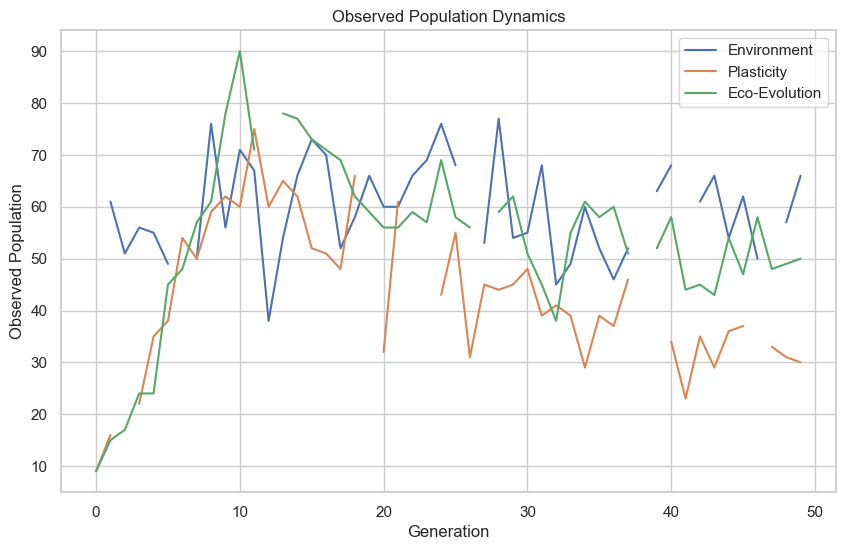

In [118]:
fig, ax = plt.subplots(
    figsize=(10,6)
)

for name,df in zip(
    ["Environment","Plasticity","Eco-Evolution"],
    [A_obs,B_obs,C_obs]
):
    
    subset = (
        df[df.replicate==0]
        .copy()
    )
    
    ax.plot(
        subset.generation,
        subset.N_obs,
        label=name
    )

ax.legend()

ax.set_title(
    "Observed Population Dynamics"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Observed Population"
)

plt.show()

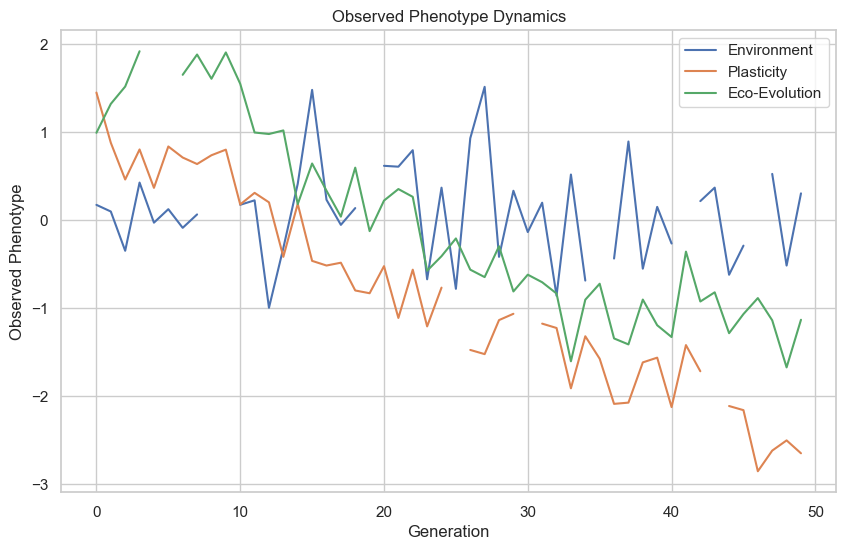

In [136]:
fig, ax = plt.subplots(
    figsize=(10,6)
)

for name,df in zip(
    ["Environment","Plasticity","Eco-Evolution"],
    [A_obs,B_obs,C_obs]
):
    
    subset = (
        df[df.replicate==0]
        .copy()
    )
    
    ax.plot(
        subset.generation,
        subset.z_obs,
        label=name
    )

ax.legend()

ax.set_title(
    "Observed Phenotype Dynamics"
)

ax.set_xlabel(
    "Generation"
)

ax.set_ylabel(
    "Observed Phenotype"
)

plt.show()

Different mechanisms give similar time series --> equifinality (structural non-identifiability)

## 7. Parameter Recovery

In previous notebooks we generated datasets using known parameters.

For example:

$$
\alpha = 0.2
$$

$$
\beta = 0.001
$$

$$
h^2 = 0.4
$$

The question is:

Can statistical inference recover these values?

Parameter recovery is a prerequisite for any meaningful ecological inference.

In [120]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import curve_fit

sns.set_theme(style="whitegrid")

In [121]:
C_obs = pd.read_csv(
    "observed_datasets/C_observed.csv"
)

### Estimating Alpha

Recall:

$$
K(z)=K_0e^{\alpha z}
$$

Taking logs:

$$
\log K
=
\log K_0
+
\alpha z
$$

Thus alpha can be estimated from regression.

In [122]:
df = C_obs.dropna().copy()

### Equilibrium approximation

In [123]:
df["logN"] = np.log(
    df["N_obs"]+1
)

In [124]:
coef = np.polyfit(
    df["z_obs"],
    df["logN"],
    1
)

alpha_est = coef[0]

print(
    "Estimated alpha:",
    alpha_est
)

Estimated alpha: -0.031891002428810565


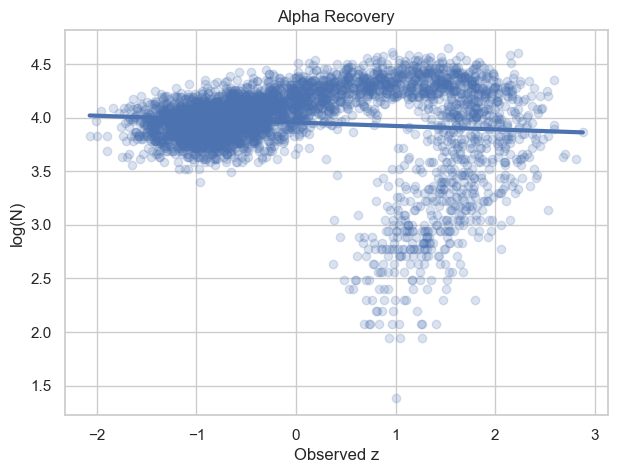

In [125]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    df["z_obs"],
    df["logN"],
    alpha=0.2
)

x=np.linspace(
    df["z_obs"].min(),
    df["z_obs"].max(),
    100
)

y=coef[0]*x+coef[1]

plt.plot(
    x,
    y,
    linewidth=3
)

plt.title(
    "Alpha Recovery"
)

plt.xlabel(
    "Observed z"
)

plt.ylabel(
    "log(N)"
)

plt.show()

In [126]:
rep0 = (
    C_obs[
        C_obs.replicate==0
    ]
    .dropna()
)

In [127]:
rep0["dz"] = (
    rep0["z_obs"]
    .diff()
)

In [128]:
rep0 = rep0.dropna()

In [129]:
coef = np.polyfit(
    rep0["N_obs"],
    rep0["dz"],
    1
)

beta_est = -coef[0]

print(
    "Estimated beta:",
    beta_est
)

Estimated beta: 0.0071188843351179115


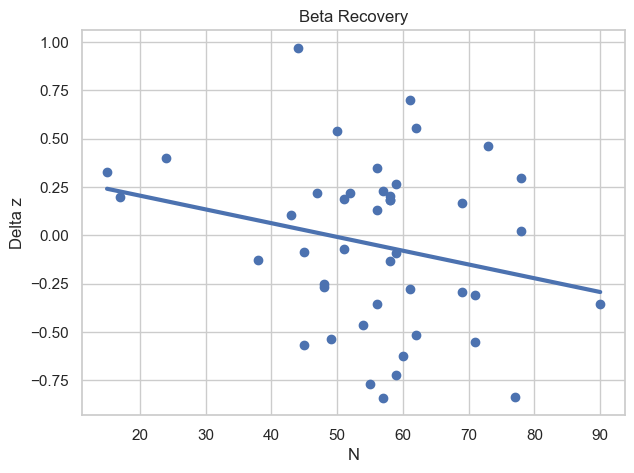

In [130]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    rep0["N_obs"],
    rep0["dz"]
)

plt.plot(
    np.sort(rep0["N_obs"]),
    np.polyval(
        coef,
        np.sort(rep0["N_obs"])
    ),
    linewidth=3
)

plt.title(
    "Beta Recovery"
)

plt.xlabel(
    "N"
)

plt.ylabel(
    "Delta z"
)

plt.show()

In [131]:
rep0 = (
    C_obs[
        C_obs.replicate==0
    ]
    .dropna()
)

In [132]:
parent = (
    rep0["z_obs"]
    .iloc[:-1]
)

offspring = (
    rep0["z_obs"]
    .iloc[1:]
)

In [133]:
coef = np.polyfit(
    parent,
    offspring,
    1
)

h2_est = coef[0]

print(
    "Estimated h²:",
    h2_est
)

Estimated h²: 0.9184636804010567


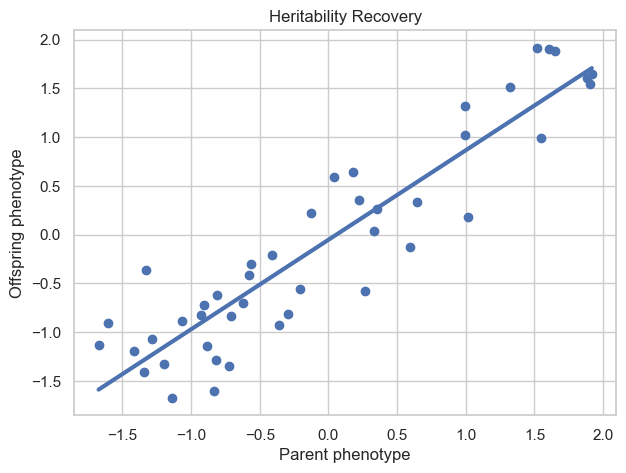

In [134]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    parent,
    offspring
)

plt.plot(
    np.sort(parent),
    np.polyval(
        coef,
        np.sort(parent)
    ),
    linewidth=3
)

plt.title(
    "Heritability Recovery"
)

plt.xlabel(
    "Parent phenotype"
)

plt.ylabel(
    "Offspring phenotype"
)

plt.show()

In [135]:
summary = pd.DataFrame({

    "parameter":[
        "alpha",
        "beta",
        "heritability"
    ],

    "estimate":[
        alpha_est,
        beta_est,
        h2_est
    ]

})

summary

,parameter,estimate
0,alpha,-0.031891
1,beta,0.007119
2,heritability,0.918464


In section 4:   

alpha=0.2  
beta≈0.001  
h2=0.4

Parameter recovery fails for all three parameters.

This is not a coding problem.

This is evidence that abundance–phenotype time series alone may not contain enough information to uniquely identify eco-evolutionary parameters.

## 8. Bayesian Inference

Model:

$$
z_{t+1}
=
a+bN_t+\epsilon
$$

where

$$
\epsilon
\sim N(0,\sigma)
$$

Goal:

Estimate posterior distribution of

$$
b
$$

A negative value supports density-dependent trait change.

In [138]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az

import ipywidgets

sns.set_theme(style="whitegrid")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\hi\anaconda3\envs\Pop_size_culture_evol\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [139]:
C_obs = pd.read_csv(
    "observed_datasets/C_observed.csv"
)

In [140]:
df = (
    C_obs
    .query("replicate==0")
    .copy()
)

In [141]:
df = df[
    ["generation",
     "N_obs",
     "z_obs"]
]

In [142]:
df = df.dropna()

In [143]:
df["z_next"] = (
    df["z_obs"]
    .shift(-1)
)

In [144]:
df = df.dropna()

In [145]:
N = df["N_obs"].values

z_next = df["z_next"].values

In [147]:
with pm.Model() as model:
    
    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=10
    )
    
    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=10
    )
    
    sigma = pm.HalfNormal(
        "sigma",
        sigma=5
    )
    
    mu = (
        intercept
        +
        beta*N
    )
    
    likelihood = pm.Normal(
        "likelihood",
        mu=mu,
        sigma=sigma,
        observed=z_next
    )
    
    trace = pm.sample(
        2000,
        tune=1000,
        target_accept=0.9,
        return_inferencedata=True
    )

 Progress                       Draw   Divergences   Step size   Grad evals   Speed          Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   3000   0             0.221       7            6.95 draws/s   0:07:11   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   3000   0             0.240       15           7.45 draws/s   0:06:42   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   3000   0             0.275       15           6.84 draws/s   0:07:18   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   3000   0             0.204       31           6.70 draws/s   0:07:27   0:00:00

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 477 seconds.


In [148]:
az.summary(
    trace,
    round_to=3
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,0.137,0.600,-1.013,1.253,0.012,0.010,2742.408,2921.405,1.001
beta,-0.005,0.011,-0.024,0.015,0.000,0.000,2712.524,2898.630,1.001
sigma,1.119,0.126,0.893,1.362,0.002,0.002,3423.312,3346.800,1.001


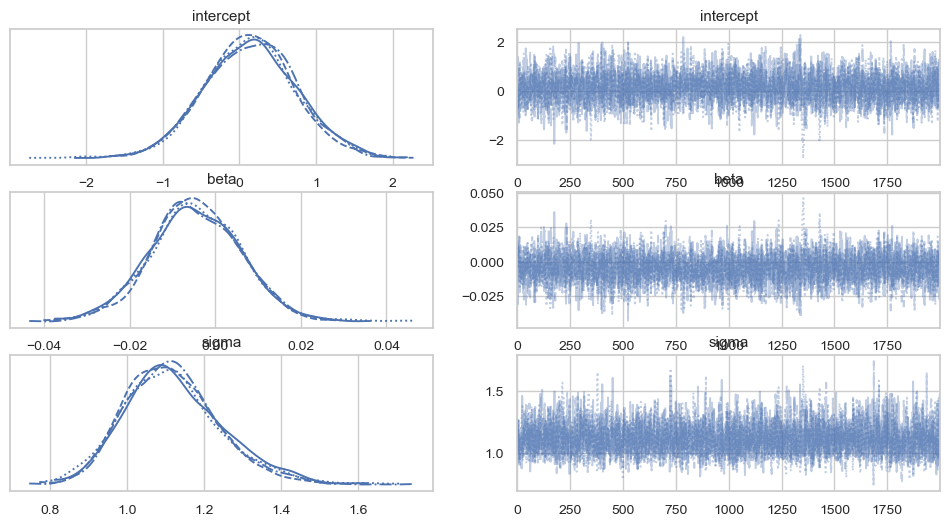

In [149]:
az.plot_trace(
    trace
)

plt.show()

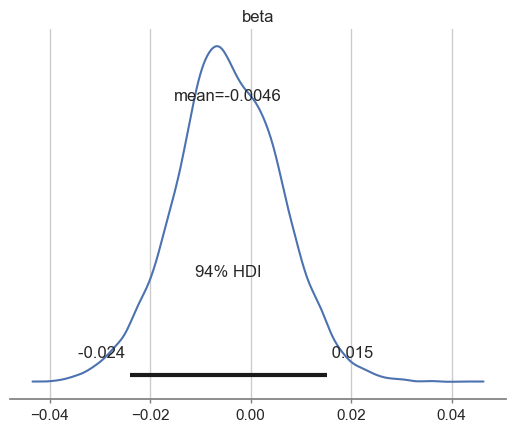

In [150]:
az.plot_posterior(
    trace,
    var_names=["beta"]
)

plt.show()

### Interpretation

Posterior mean:

$$
E(\beta)
$$

95% credible interval:

$$
CI_{95}
$$

If the interval excludes zero:

evidence exists for a density–phenotype relationship.

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:05

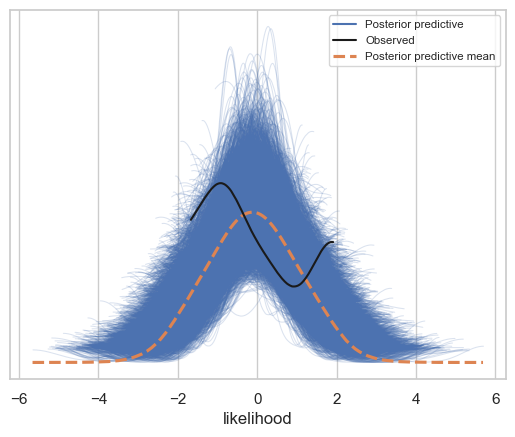

In [156]:
with model:
    
    ppc = pm.sample_posterior_predictive(
        trace,
        return_inferencedata=True
    )

az.plot_ppc(ppc)

plt.show()

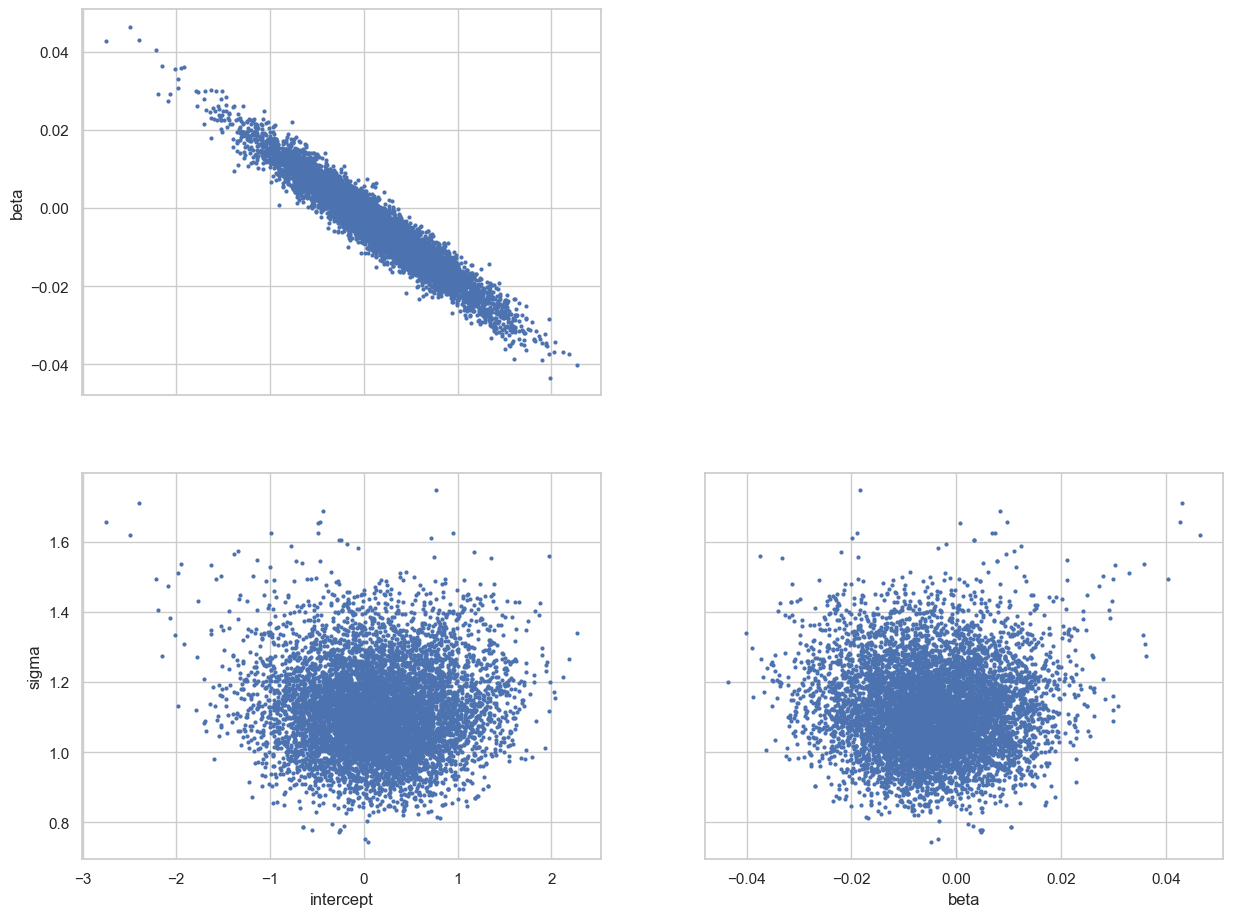

In [154]:
az.plot_pair(
    trace,
    var_names=[
        "intercept",
        "beta",
        "sigma"
    ]
)

plt.show()

In [155]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,0.137,0.600,-1.013,1.253,0.012,0.010,2742.0,2921.0,1.0
beta,-0.005,0.011,-0.024,0.015,0.000,0.000,2713.0,2899.0,1.0
sigma,1.119,0.126,0.893,1.362,0.002,0.002,3423.0,3347.0,1.0


### Interpretation

β < 0, but 95% HDI includes 0,
Feedback signal exist but very weak.

σ=1.119
A large number of variations that the model cannot explain.
Simple bayesian regression cannot identify.

## 9. Model Comparison

Which hypothesis generated the observed data?

Environmental only vs. Plasticity vs. Eco-evolutio

M1 Environmental only

$$
z_{t+1}
=
a
+
\epsilon_t
$$

M2 Plasticity 

$$
z_{t+1}
=
a
+
bN_t
+
\epsilon_t
$$

M3 Eco-evol proxy 

$$
z_{t+1}
=
a
+
bN_t
+
cz_t
+
\epsilon_t
$$

In [158]:
import numpy as np
import pandas as pd

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [159]:
A = pd.read_csv(
    "observed_datasets/A_observed.csv"
)

B = pd.read_csv(
    "observed_datasets/B_observed.csv"
)

C = pd.read_csv(
    "observed_datasets/C_observed.csv"
)

In [160]:
replicate = 0

A = A[A.replicate==replicate]
B = B[B.replicate==replicate]
C = C[C.replicate==replicate]

In [161]:
A = A.dropna()
B = B.dropna()
C = C.dropna()

In [162]:
for df in [A,B,C]:
    
    df["z_next"] = (
        df["z_obs"]
        .shift(-1)
    )

In [163]:
A=A.dropna()
B=B.dropna()
C=C.dropna()

In [164]:
def fit_M1(df):
    
    with pm.Model() as model:
        
        intercept = pm.Normal(
            "intercept",
            0,
            10
        )
        
        sigma = pm.HalfNormal(
            "sigma",
            5
        )
        
        pm.Normal(
            "obs",
            mu=intercept,
            sigma=sigma,
            observed=df["z_next"]
        )
        
        trace = pm.sample(
            1000,
            tune=1000,
            progressbar=False,
            idata_kwargs={
                "log_likelihood":True
            }
        )
        
    return trace

In [165]:
def fit_M2(df):
    
    N = df["N_obs"].values
    
    with pm.Model() as model:
        
        intercept = pm.Normal(
            "intercept",
            0,
            10
        )
        
        beta = pm.Normal(
            "beta",
            0,
            10
        )
        
        sigma = pm.HalfNormal(
            "sigma",
            5
        )
        
        mu = (
            intercept
            +
            beta*N
        )
        
        pm.Normal(
            "obs",
            mu=mu,
            sigma=sigma,
            observed=df["z_next"]
        )
        
        trace = pm.sample(
            1000,
            tune=1000,
            progressbar=False,
            idata_kwargs={
                "log_likelihood":True
            }
        )
        
    return trace

In [166]:
def fit_M3(df):
    
    N = df["N_obs"].values
    
    z = df["z_obs"].values
    
    with pm.Model() as model:
        
        intercept = pm.Normal(
            "intercept",
            0,
            10
        )
        
        beta_N = pm.Normal(
            "beta_N",
            0,
            10
        )
        
        beta_z = pm.Normal(
            "beta_z",
            0,
            10
        )
        
        sigma = pm.HalfNormal(
            "sigma",
            5
        )
        
        mu = (
            intercept
            +
            beta_N*N
            +
            beta_z*z
        )
        
        pm.Normal(
            "obs",
            mu=mu,
            sigma=sigma,
            observed=df["z_next"]
        )
        
        trace = pm.sample(
            1000,
            tune=1000,
            progressbar=False,
            idata_kwargs={
                "log_likelihood":True
            }
        )
        
    return trace

In [167]:
trace_M1 = fit_M1(C)

trace_M2 = fit_M2(C)

trace_M3 = fit_M3(C)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 66 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 234 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_N, beta_z, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 374 seconds.


In [168]:
waic_M1 = az.waic(trace_M1)

waic_M2 = az.waic(trace_M2)

waic_M3 = az.waic(trace_M3)

C:\Users\hi\anaconda3\envs\Pop_size_culture_evol\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\hi\anaconda3\envs\Pop_size_culture_evol\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 

Strong autocorrelation in time series

In [169]:
loo_M1 = az.loo(trace_M1)

loo_M2 = az.loo(trace_M2)

loo_M3 = az.loo(trace_M3)

In [170]:
comparison = pd.DataFrame({

    "Model":[
        "M1",
        "M2",
        "M3"
    ],

    "WAIC":[
        waic_M1.elpd_waic,
        waic_M2.elpd_waic,
        waic_M3.elpd_waic
    ],

    "LOO":[
        loo_M1.elpd_loo,
        loo_M2.elpd_loo,
        loo_M3.elpd_loo
    ]
})

comparison

,Model,WAIC,LOO
0,M1,-66.974859,-66.981918
1,M2,-68.277520,-68.331974
2,M3,-27.409474,-27.463050


M3 >> M1 > M2 

Z_t is very important in prediction

system has memory


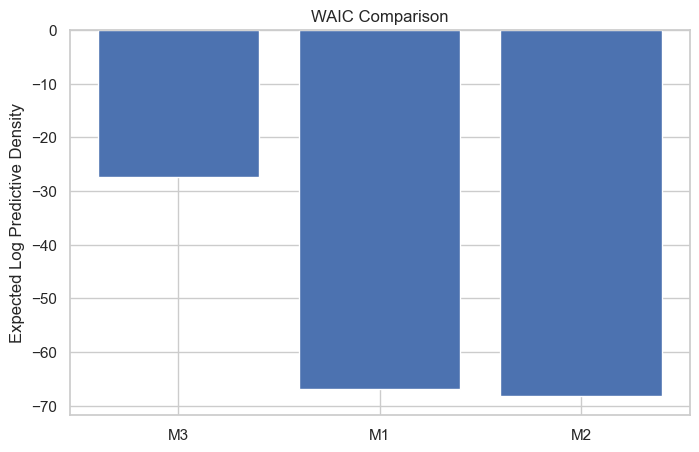

In [172]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    comparison["Model"],
    comparison["WAIC"]
)

plt.title(
    "WAIC Comparison"
)

plt.ylabel(
    "Expected Log Predictive Density"
)

plt.show()

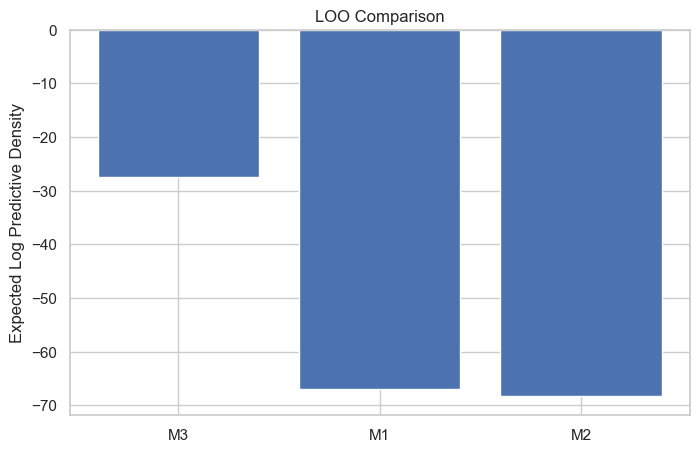

In [173]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    comparison["Model"],
    comparison["LOO"]
)

plt.title(
    "LOO Comparison"
)

plt.ylabel(
    "Expected Log Predictive Density"
)

plt.show()

### Interpretation

Higher WAIC and LOO values indicate better predictive performance.

Possible outcomes:

M1 best

Environmental forcing sufficient.

M2 best

Plasticity sufficient.

M3 best

Additional temporal structure improves prediction.

This does not yet prove eco-evolutionary feedback.

However it indicates whether more complex causal hypotheses are supported by the data.

## 10 . A) Latent Phenotype State-Space Model

### Research Question

Can the true phenotype trajectory be recovered from noisy observations?

---

In previous notebooks we analysed:

$$
z_{obs}
$$

However observations contain measurement error.

The true phenotype:

$$
z_t
$$

is hidden.

This notebook introduces a state-space model.

---

## State Process

The latent phenotype evolves through time:

$$
z_t
=
z_{t-1}
+
\eta_t
$$

where

$$
\eta_t
\sim N(0,\sigma_{state})
$$

---

## Observation Process

Observed phenotype is noisy:

$$
z_{obs,t}
=
z_t
+
\epsilon_t
$$

where

$$
\epsilon_t
\sim N(0,\sigma_{obs})
$$

---

## Goal

Estimate:

- latent phenotype trajectory
- process variance
- observation variance

from noisy observations alone.

In [174]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az

sns.set_theme(style="whitegrid")

In [175]:
print(pm.__version__)
print(az.__version__)

5.28.4
0.23.4


### Load Observed Dataset

We use the eco-evolutionary dataset generated previously.

In [176]:
C_obs = pd.read_csv(
    "observed_datasets/C_observed.csv"
)

In [177]:
replicate = 0

df = (
    C_obs[
        C_obs["replicate"] == replicate
    ]
    .copy()
)

In [178]:
df.head()

,replicate,generation,N,G,z,model,N_obs,z_obs
0,0,0,20.000000,1.000000,1.000000,eco_evolution,9.0,0.991604
1,0,1,26.690031,1.240000,1.304439,eco_evolution,15.0,1.319830
2,0,2,35.170934,1.453240,1.385390,eco_evolution,17.0,1.516473
3,0,3,45.488764,1.632556,1.602006,eco_evolution,24.0,1.917554
4,0,4,57.676410,1.770601,1.710863,eco_evolution,24.0,NaN


In [179]:
df = df.sort_values(
    "generation"
)

In [180]:
df = df[
    [
        "generation",
        "z",
        "z_obs"
    ]
]

### Visual Inspection

Compare true and observed phenotype.

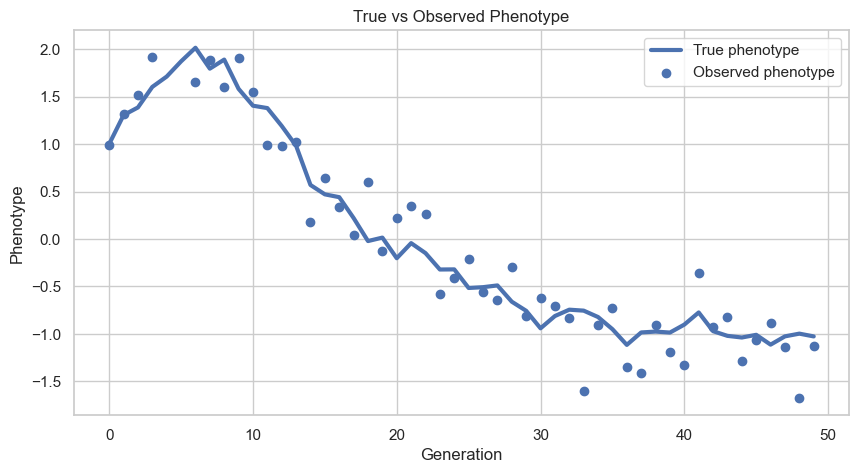

In [181]:
plt.figure(figsize=(10,5))

plt.plot(
    df["generation"],
    df["z"],
    label="True phenotype",
    linewidth=3
)

plt.scatter(
    df["generation"],
    df["z_obs"],
    label="Observed phenotype"
)

plt.xlabel("Generation")
plt.ylabel("Phenotype")

plt.title(
    "True vs Observed Phenotype"
)

plt.legend()

plt.show()

In [182]:
df2 = df.dropna().copy()

In [183]:
z_obs = df2["z_obs"].values

T = len(z_obs)

print(T)

48


### State-Space Model

Latent state:

$$
z_t
$$

Observation:

$$
z_{obs,t}
\sim
N(z_t,\sigma_{obs})
$$

State dynamics:

$$
z_t
\sim
N(z_{t-1},\sigma_{state})
$$

This is a Gaussian random walk.

In [184]:
with pm.Model() as ssm:
    
    sigma_state = pm.HalfNormal(
        "sigma_state",
        sigma=1
    )
    
    sigma_obs = pm.HalfNormal(
        "sigma_obs",
        sigma=1
    )

In [185]:
with ssm:
    
    z_latent = pm.GaussianRandomWalk(
        "z_latent",
        sigma=sigma_state,
        shape=T
    )

C:\Users\hi\anaconda3\envs\Pop_size_culture_evol\Lib\site-packages\pymc\distributions\timeseries.py:291: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


In [186]:
with ssm:
    
    obs = pm.Normal(
        "obs",
        mu=z_latent,
        sigma=sigma_obs,
        observed=z_obs
    )

### Bayesian Inference

Estimate posterior distributions for:

$$
\sigma_{state}
$$

and

$$
\sigma_{obs}
$$

as well as the latent trajectory.

In [187]:
with ssm:
    
    trace_ssm = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.95,
        return_inferencedata=True
    )

 Progress                       Draw   Divergences   Step size   Grad evals   Speed          Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.190       15           3.48 draws/s   0:19:08   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.222       15           3.72 draws/s   0:17:54   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.211       15           3.74 draws/s   0:17:50   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.230       15           3.53 draws/s   0:18:52   0:00:00

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1176 seconds.


In [189]:
az.summary(
    trace_ssm,
    var_names=[
        "sigma_state",
        "sigma_obs"
    ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_state,0.239,0.058,0.141,0.349,0.002,0.001,1324.0,1843.0,1.0
sigma_obs,0.251,0.049,0.160,0.346,0.001,0.001,1497.0,884.0,1.0


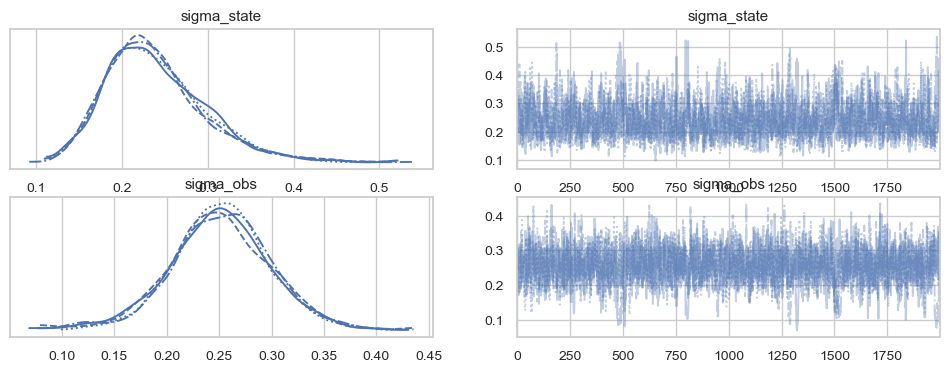

In [190]:
az.plot_trace(
    trace_ssm,
    var_names=[
        "sigma_state",
        "sigma_obs"
    ]
)

plt.show()

### Posterior Interpretation

Large:

$$
\sigma_{obs}
$$

means observations are noisy.

Large:

$$
\sigma_{state}
$$

means phenotype changes rapidly through time.

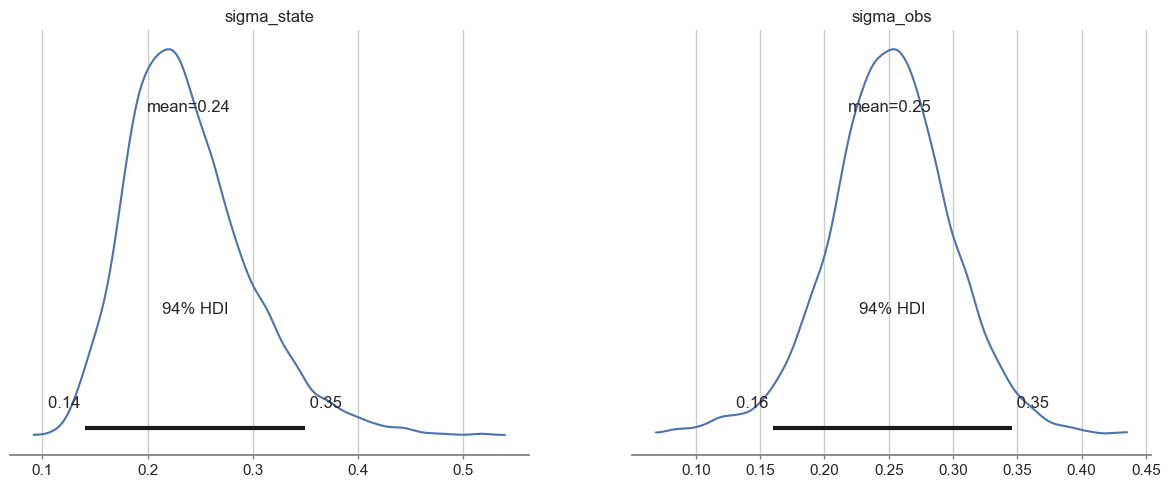

In [191]:
az.plot_posterior(
    trace_ssm,
    var_names=[
        "sigma_state",
        "sigma_obs"
    ]
)

plt.show()

Trait changes slowly.

The system is relatively stable.

Observe error = real dynamic

In [192]:
latent_mean = (
    trace_ssm.posterior[
        "z_latent"
    ]
    .mean(
        dim=["chain","draw"]
    )
    .values
)

In [193]:
latent_hdi = az.hdi(
    trace_ssm,
    var_names=["z_latent"],
    hdi_prob=0.95
)

In [194]:
lower = latent_hdi[
    "z_latent"
].sel(
    hdi="lower"
).values

upper = latent_hdi[
    "z_latent"
].sel(
    hdi="higher"
).values

## Latent State Recovery

Compare:

- true phenotype
- noisy observations
- estimated latent state

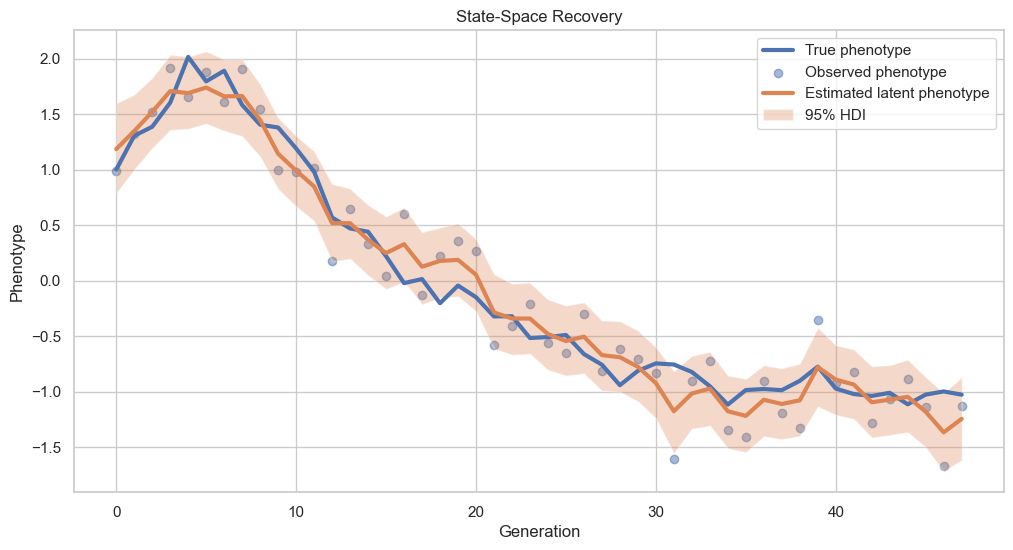

In [195]:
time = np.arange(T)

plt.figure(
    figsize=(12,6)
)

plt.plot(
    time,
    df2["z"].values,
    linewidth=3,
    label="True phenotype"
)

plt.scatter(
    time,
    z_obs,
    alpha=0.5,
    label="Observed phenotype"
)

plt.plot(
    time,
    latent_mean,
    linewidth=3,
    label="Estimated latent phenotype"
)

plt.fill_between(
    time,
    lower,
    upper,
    alpha=0.3,
    label="95% HDI"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Phenotype"
)

plt.title(
    "State-Space Recovery"
)

plt.legend()

plt.show()

In [196]:
corr = np.corrcoef(
    latent_mean,
    df2["z"].values
)[0,1]

print(
    "Correlation:",
    corr
)

Correlation: 0.9852065872959525


Latent state recovery is excellent.

### Recovery Metric

Correlation between:

estimated latent state

and

true latent state

provides a simple recovery score.

$$
r
=
Cor(
\hat z_t,
z_t
)
$$

Interpretation:

- r ≈ 1 : excellent recovery
- r ≈ 0 : no recovery

In [197]:
rmse = np.sqrt(
    np.mean(
        (
            latent_mean
            -
            df2["z"].values
        )**2
    )
)

print(
    "RMSE:",
    rmse
)

RMSE: 0.174281525493232


Minor error

Hidden trajectories are recoverable.
Observation noise is not the main problem.

## 10. B) Latent Genetic State Model

Can hidden breeding values be recovered from phenotype observations?

In section 10A we estimated:

$$
z_t
$$

Now we introduce:

$$
G_t
$$

the breeding value.

---

Phenotype:

$$
z_t
=
G_t
+
E_t
$$

where:

$$
E_t
\sim N(0,\sigma_E)
$$

---

State Process

$$
G_t
=
G_{t-1}
+
\eta_t
$$

where

$$
\eta_t
\sim N(0,\sigma_G)
$$

---

Observation Process

$$
z_{obs,t}
=
G_t
+
\epsilon_t
$$

where

$$
\epsilon_t
\sim N(0,\sigma_{obs})
$$

---

Goal

Recover:

- latent breeding value
- genetic variance
- observation variance

In [198]:
C_obs = pd.read_csv(
    "observed_datasets/C_observed.csv"
)

In [199]:
replicate = 0

df = (
    C_obs[
        C_obs.replicate==replicate
    ]
    .copy()
)

In [200]:
df = df.dropna()

In [201]:
z_obs = df["z_obs"].values

T = len(z_obs)

### Genetic Random Walk

The breeding value evolves through time:

$$
G_t
=
G_{t-1}
+
\eta_t
$$

This approximates slow evolutionary change.

In [202]:
with pm.Model() as genetic_ssm:
    
    sigma_G = pm.HalfNormal(
        "sigma_G",
        sigma=1
    )
    
    sigma_obs = pm.HalfNormal(
        "sigma_obs",
        sigma=1
    )

In [203]:
with genetic_ssm:
    
    G = pm.GaussianRandomWalk(
        "G",
        sigma=sigma_G,
        init_dist=pm.Normal.dist(
            mu=z_obs[0],
            sigma=1
        ),
        shape=T
    )

In [204]:
with genetic_ssm:
    
    z_hat = pm.Normal(
        "z_hat",
        mu=G,
        sigma=sigma_obs,
        observed=z_obs
    )

In [206]:
with genetic_ssm:
    
    trace_G = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.95,
        return_inferencedata=True
    )

 Progress                       Draw   Divergences   Step size   Grad evals   Speed          Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.226       15           4.25 draws/s   0:15:40   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.186       31           3.92 draws/s   0:17:01   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.204       31           4.24 draws/s   0:15:43   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━   4000   0             0.191       15           4.11 draws/s   0:16:14   0:00:00

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1047 seconds.


In [207]:
az.summary(
    trace_G,
    var_names=[
        "sigma_G",
        "sigma_obs"
    ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_G,0.270,0.067,0.163,0.401,0.003,0.002,698.0,950.0,1.01
sigma_obs,0.239,0.059,0.126,0.357,0.003,0.002,587.0,457.0,1.01


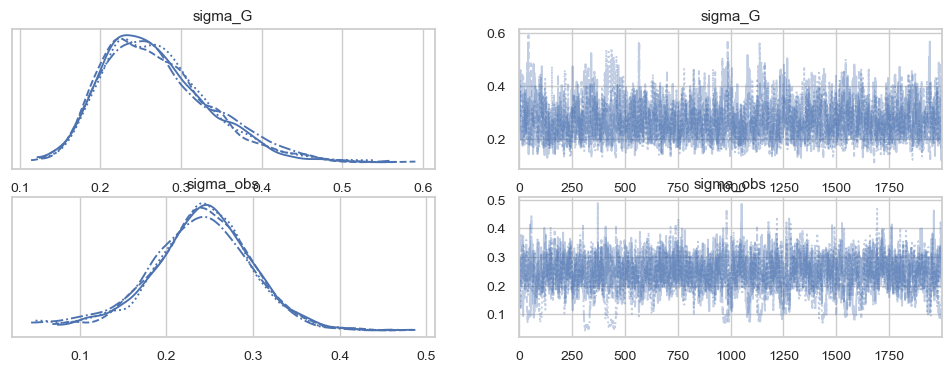

In [208]:
az.plot_trace(
    trace_G,
    var_names=[
        "sigma_G",
        "sigma_obs"
    ]
)

plt.show()

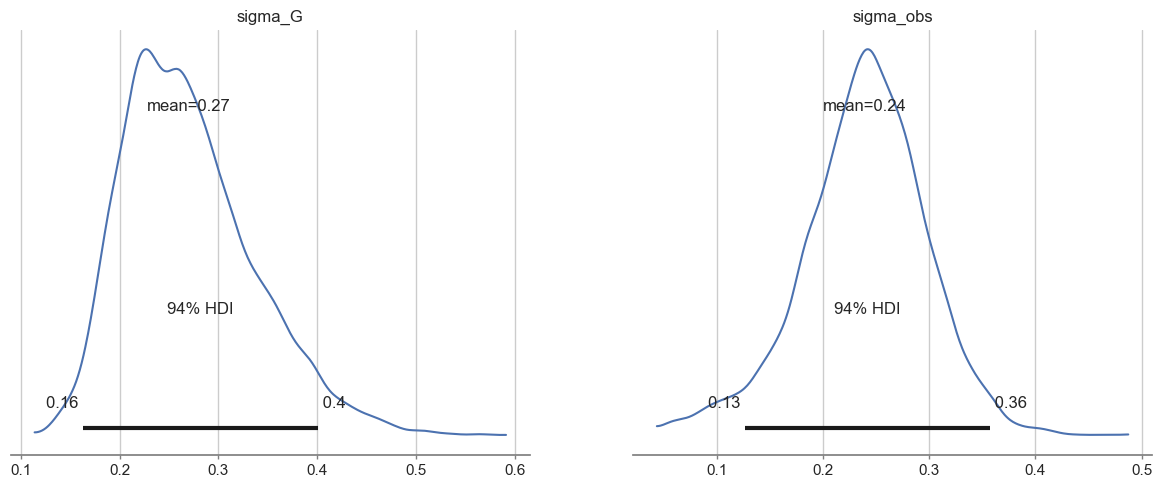

In [209]:
az.plot_posterior(
    trace_G,
    var_names=[
        "sigma_G",
        "sigma_obs"
    ]
)

plt.show()

### Recover Breeding Value

Posterior mean:

$$
E[G_t]
$$

will be used as estimated breeding value.

In [210]:
G_mean = (
    trace_G.posterior["G"]
    .mean(
        dim=["chain","draw"]
    )
    .values
)

In [211]:
hdi_G = az.hdi(
    trace_G,
    var_names=["G"]
)

In [212]:
lower = (
    hdi_G["G"]
    .sel(hdi="lower")
    .values
)

upper = (
    hdi_G["G"]
    .sel(hdi="higher")
    .values
)

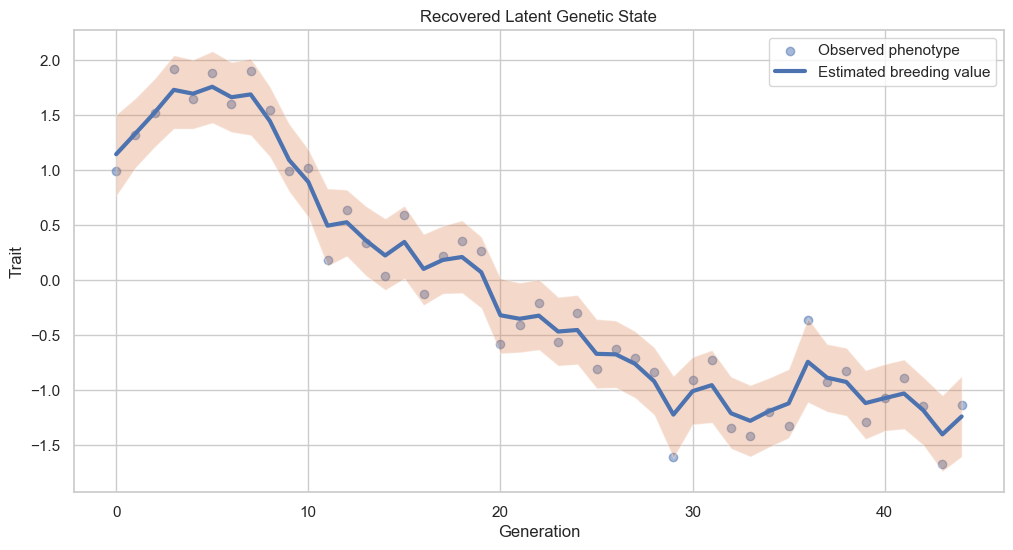

In [213]:
plt.figure(
    figsize=(12,6)
)

time=np.arange(T)

plt.scatter(
    time,
    z_obs,
    alpha=0.5,
    label="Observed phenotype"
)

plt.plot(
    time,
    G_mean,
    linewidth=3,
    label="Estimated breeding value"
)

plt.fill_between(
    time,
    lower,
    upper,
    alpha=0.3
)

plt.xlabel("Generation")
plt.ylabel("Trait")

plt.title(
    "Recovered Latent Genetic State"
)

plt.legend()

plt.show()

### Interpretation

If the estimated trajectory is smooth,

the model attributes variation to:

$$
G_t
$$

rather than observation noise.

If uncertainty bands are wide,

genetic state recovery is weak.

In [214]:
az.summary(trace_G)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
G[0],1.145,0.197,0.767,1.505,0.003,0.002,3379.0,6029.0,1.00
G[1],1.333,0.168,1.023,1.654,0.002,0.002,7010.0,6133.0,1.00
G[2],1.522,0.165,1.211,1.832,0.002,0.002,6824.0,5411.0,1.00
G[3],1.730,0.178,1.378,2.044,0.003,0.002,2799.0,5541.0,1.00
G[4],1.695,0.167,1.377,2.003,0.002,0.002,6788.0,5426.0,1.00
G[5],1.758,0.173,1.430,2.080,0.003,0.002,3588.0,4973.0,1.00
G[6],1.663,0.166,1.347,1.982,0.002,0.002,5811.0,5370.0,1.00
G[7],1.688,0.187,1.318,2.014,0.004,0.002,2031.0,4731.0,1.00
G[8],1.446,0.171,1.122,1.760,0.003,0.002,4086.0,4877.0,1.00
G[9],1.092,0.164,0.807,1.422,0.002,0.002,6954.0,5944.0,1.00


The latent breeding value could not be clearly distinguished from observation noise.

Both variance components converged to similar values.

This suggests partial non-identifiability of the genetic state when phenotype observations are analysed without ecological information.


## 10. C) Mechanistic Eco-Evolutionary State-Space Framework (lite)

### Research Question

Can eco-evolutionary feedbacks be detected from abundance–phenotype time series?

Previous notebooks established:

- ecological dynamics
- trait dynamics
- evolutionary dynamics
- observation processes

This notebook defines the complete mechanistic system that will be used in subsequent analyses.

The objective is not yet Bayesian inference.

The objective is to formalise the latent state equations.

---

State variables

$$
N_t
$$

Population abundance

$$
G_t
$$

Breeding value

$$
z_t
$$

Phenotype

---

Phenotype equation

$$
z_t = G_t
$$

---

Trait-dependent carrying capacity

$$
K_t
=
K_0 e^{\alpha G_t}
$$

---

Population dynamics

$$
N_{t+1}
=
N_t
+
rN_t
\left(
1-\frac{N_t}{K_t}
\right)
$$

---

Evolutionary dynamics

$$
G_{t+1}
=
G_t
-
\beta N_t
+
\epsilon_G
$$

where

$$
\epsilon_G
\sim
N(0,\sigma_G)
$$

---

Feedback loop

$$
G_t
\rightarrow
K_t
\rightarrow
N_t
\rightarrow
G_{t+1}
$$

This closes the eco-evolutionary loop.

### Baseline Parameters

These values will be reused in:

- Section 11
- Section 12
- Section 13

In [228]:
params = {

    "r":0.3,

    "K0":100,

    "alpha":0.4,

    "beta":0.005,

    "sigma_G":0.05,

    "T":100
}

params

{'r': 0.3, 'K0': 100, 'alpha': 0.4, 'beta': 0.005, 'sigma_G': 0.05, 'T': 100}

## Mechanistic Simulator

This simulator generates the latent ecological and evolutionary trajectories.

In [229]:
def simulate_ecoevo(params):

    T = params["T"]

    r = params["r"]

    K0 = params["K0"]

    alpha = params["alpha"]

    beta = params["beta"]

    sigma_G = params["sigma_G"]

    N = np.zeros(T)

    G = np.zeros(T)

    z = np.zeros(T)

    N[0] = 20

    G[0] = 1

    z[0] = G[0]

    for t in range(T-1):

        K = K0*np.exp(alpha*G[t])

        N[t+1] = (
            N[t]
            +
            r*N[t]*(1-N[t]/K)
        )

        G[t+1] = (
            G[t]
            -
            beta*N[t]
            +
            np.random.normal(
                0,
                sigma_G
            )
        )

        z[t+1] = G[t+1]

    return pd.DataFrame({

        "generation":
        np.arange(T),

        "N":N,

        "G":G,

        "z":z
    })

In [232]:
df = simulate_ecoevo(params)
df.head()

,generation,N,G,z
0,0,20.000000,1.000000,1.000000
1,1,25.195616,0.886661,0.886661
2,2,31.418497,0.737378,0.737378
3,3,38.639109,0.545222,0.545222
4,4,46.629530,0.493957,0.493957


### Population Dynamics

Visualise abundance through time.

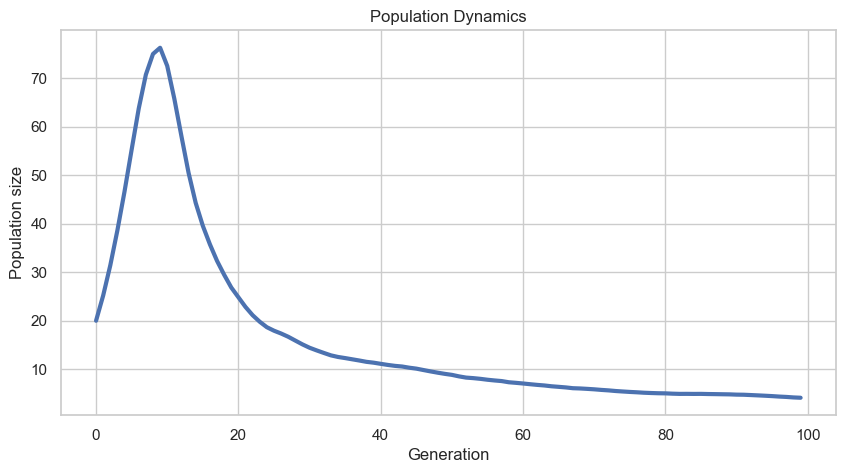

In [233]:
plt.figure(figsize=(10,5))

plt.plot(
    df["generation"],
    df["N"],
    linewidth=3
)

plt.xlabel("Generation")

plt.ylabel("Population size")

plt.title(
    "Population Dynamics"
)

plt.show()

### Evolutionary Dynamics

Visualise breeding value through time.

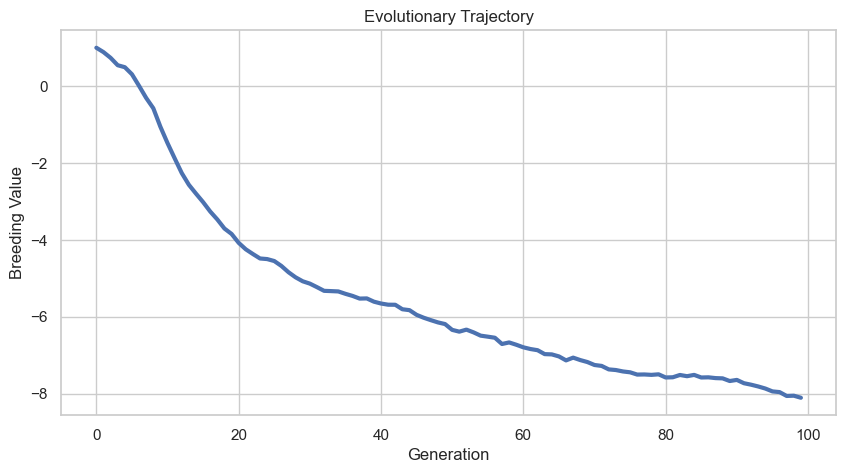

In [234]:
plt.figure(figsize=(10,5))

plt.plot(
    df["generation"],
    df["G"],
    linewidth=3
)

plt.xlabel("Generation")

plt.ylabel("Breeding Value")

plt.title(
    "Evolutionary Trajectory"
)

plt.show()

### Eco-Evolutionary Feedback

Relationship between abundance and breeding value.

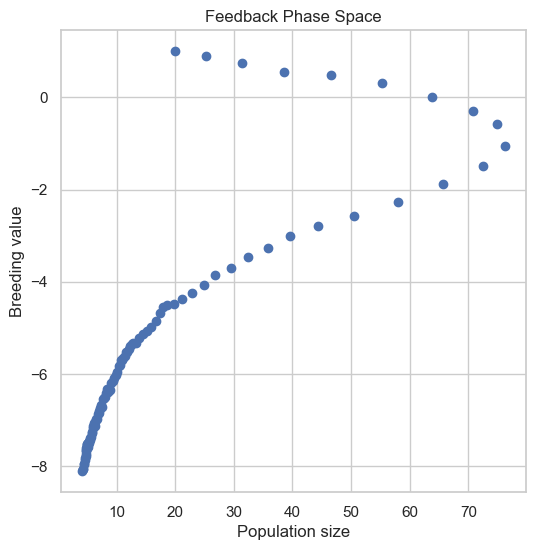

In [235]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["N"],
    df["G"]
)

plt.xlabel("Population size")

plt.ylabel("Breeding value")

plt.title(
    "Feedback Phase Space"
)

plt.show()

### Coupling Strength

Estimate the statistical relationship:

$$
G_{t+1}
=
a+bN_t
$$

This is not the true mechanism.

It is only a diagnostic summary.

In [264]:
import statsmodels.api as sm

In [265]:
X = pd.DataFrame({

    "N_t": df["N"][:-1].values,

    "G_t": df["G"][:-1].values

})

X = sm.add_constant(X)

y = df["G"][1:].values

model = sm.OLS(y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.161e+05
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          3.85e-163
Time:                        18:12:01   Log-Likelihood:                 160.65
No. Observations:                  99   AIC:                            -315.3
Df Residuals:                      96   BIC:                            -307.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0263      0.029      0.905      0.3

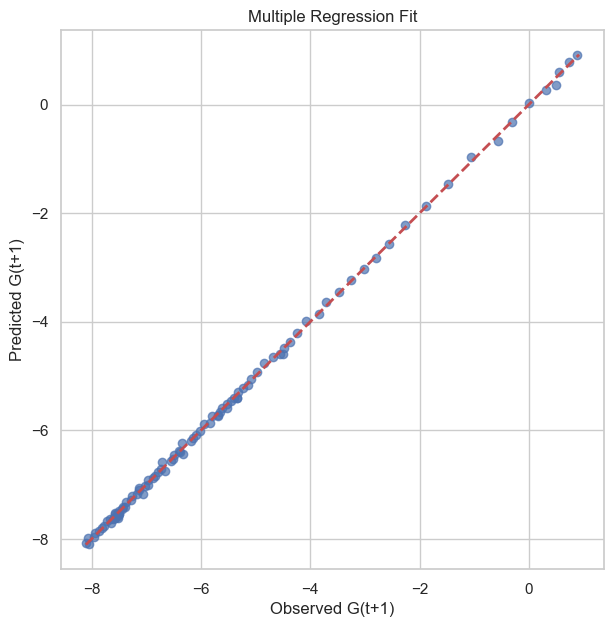

In [269]:
pred = model.predict(X)

plt.figure(figsize=(7,7))

plt.scatter(
    y,
    pred,
    alpha=0.7
)

lims = [

    min(y.min(),pred.min()),

    max(y.max(),pred.max())

]

plt.plot(
    lims,
    lims,
    "r--",
    linewidth=2
)

plt.xlabel(
    "Observed G(t+1)"
)

plt.ylabel(
    "Predicted G(t+1)"
)

plt.title(
    "Multiple Regression Fit"
)

plt.show()

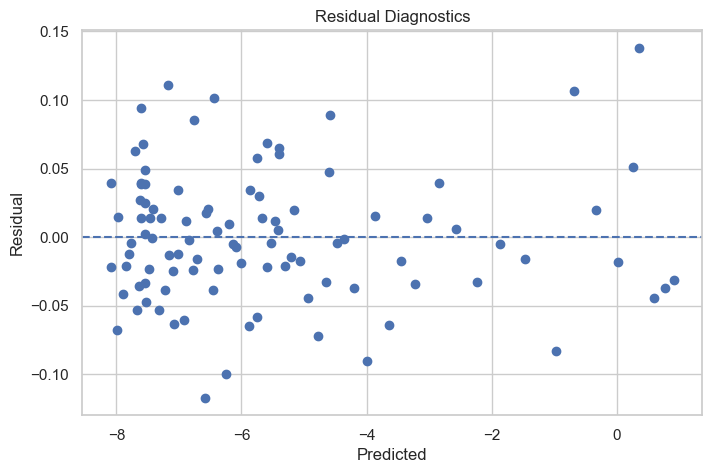

In [271]:
residuals = y-pred

plt.figure(figsize=(8,5))

plt.scatter(
    pred,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Diagnostics"
)

plt.show()

### Observation Layer

Generate realistic observations.

Observed data are not latent states.

In [240]:
def observe(df,
            sigma_N=5,
            sigma_z=0.2):

    obs = df.copy()

    obs["N_obs"] = (

        obs["N"]

        +

        np.random.normal(
            0,
            sigma_N,
            len(obs)
        )
    )

    obs["z_obs"] = (

        obs["z"]

        +

        np.random.normal(
            0,
            sigma_z,
            len(obs)
        )
    )

    return obs

In [241]:
obs = observe(df)

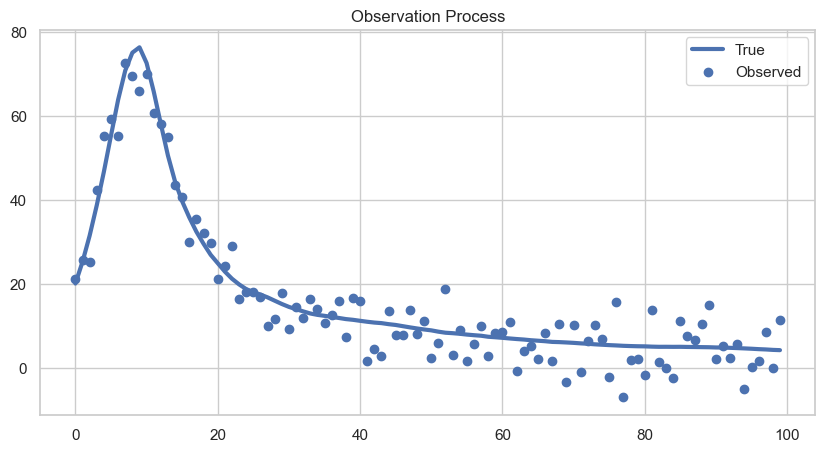

In [242]:
plt.figure(figsize=(10,5))

plt.plot(
    obs["generation"],
    obs["N"],
    linewidth=3,
    label="True"
)

plt.scatter(
    obs["generation"],
    obs["N_obs"],
    label="Observed"
)

plt.legend()

plt.title(
    "Observation Process"
)

plt.show()

### Export

The simulator becomes the engine for Notebook 11.

Notebook 11 will repeatedly vary:

- time series length
- observation noise
- heritability proxy
- feedback strength

to determine when eco-evolutionary feedback becomes statistically identifiable.

In [243]:
df.to_csv(
    "10C_latent_states.csv",
    index=False
)

obs.to_csv(
    "10C_observed_states.csv",
    index=False
)

Current limitation

The statistical model identifies feedback through linear regression.

Future versions will use:

- Bayesian state-space models
- Hidden Markov structures
- Full latent eco-evolutionary dynamics

to estimate feedback strength directly.


## 11. Identifiability Analysis

### Research Question

Can eco-evolutionary feedback parameters be recovered from abundance–phenotype time series?

---

True mechanism

$$
G_{t+1}
=
G_t
-
\beta N_t
+
\epsilon
$$

---

Detection criterion

A feedback is considered recovered if:

$$
\hat{\beta}<0
$$

and

$$
p<0.05
$$

for the density effect.

---

This Section evaluates:

- time-series length
- feedback strength
- process noise

on parameter recovery.

In [273]:
def simulate_ecoevo(
    T,
    alpha,
    beta,
    sigma_G
):

    r = 0.3
    K0 = 100

    N = np.zeros(T)

    G = np.zeros(T)

    N[0] = 20

    G[0] = 1

    for t in range(T-1):

        K = K0*np.exp(
            alpha*G[t]
        )

        N[t+1] = (

            N[t]

            +

            r*N[t]*(
                1-N[t]/K
            )
        )

        G[t+1] = (

            G[t]

            -

            beta*N[t]

            +

            np.random.normal(
                0,
                sigma_G
            )
        )

    return N,G

In [274]:
def estimate_beta(
    N,
    G
):

    X = pd.DataFrame({

        "N_t":
        N[:-1],

        "G_t":
        G[:-1]

    })

    X = sm.add_constant(X)

    y = G[1:]

    fit = sm.OLS(
        y,
        X
    ).fit()

    return {

        "beta_hat":
        fit.params["N_t"],

        "p":
        fit.pvalues["N_t"],

        "r2":
        fit.rsquared

    }

### Experiment 1

Effect of time-series length.

In [275]:
lengths = [

    20,
    50,
    100,
    200
]

records=[]

In [276]:
for T in lengths:

    recovered=[]

    beta_est=[]

    for rep in range(100):

        N,G = simulate_ecoevo(

            T=T,

            alpha=0.4,

            beta=0.005,

            sigma_G=0.05
        )

        res = estimate_beta(
            N,
            G
        )

        beta_est.append(
            res["beta_hat"]
        )

        recovered.append(

            (res["beta_hat"]<0)

            &

            (res["p"]<0.05)

        )

    records.append({

        "T":T,

        "recovery":
        np.mean(
            recovered
        ),

        "beta_mean":
        np.mean(
            beta_est
        )

    })

In [277]:
length_df = pd.DataFrame(
    records
)

length_df

,T,recovery,beta_mean
0,20,1.0,-0.004988
1,50,1.0,-0.004997
2,100,1.0,-0.004983
3,200,1.0,-0.004854


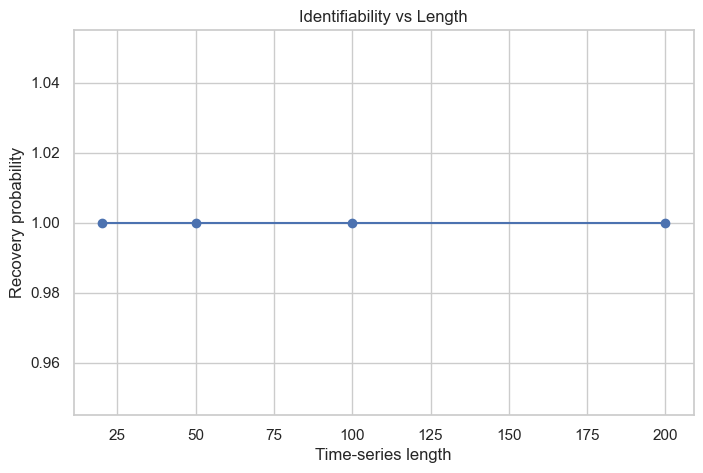

In [278]:
plt.figure(
    figsize=(8,5)
)

plt.plot(

    length_df["T"],

    length_df["recovery"],

    marker="o"
)

plt.xlabel(
    "Time-series length"
)

plt.ylabel(
    "Recovery probability"
)

plt.title(
    "Identifiability vs Length"
)

plt.show()

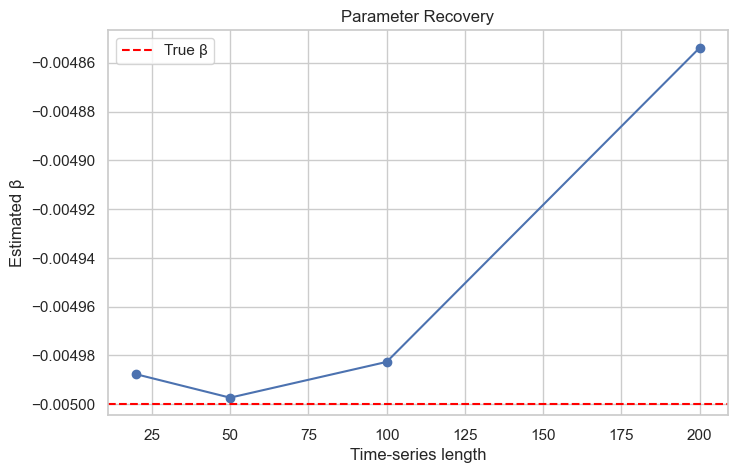

In [279]:
plt.figure(
    figsize=(8,5)
)

plt.plot(

    length_df["T"],

    length_df["beta_mean"],

    marker="o"
)

plt.axhline(
    -0.005,
    color="red",
    linestyle="--",
    label="True β"
)

plt.legend()

plt.xlabel(
    "Time-series length"
)

plt.ylabel(
    "Estimated β"
)

plt.title(
    "Parameter Recovery"
)

plt.show()

### Experiment 2

Effect of observation noise.

In [280]:
noise_levels = [

    0.01,
    0.05,
    0.1,
    0.2,
    0.5
]

records=[]

In [281]:
for noise in noise_levels:

    recovered=[]

    beta_est=[]

    for rep in range(100):

        N,G = simulate_ecoevo(

            T=100,

            alpha=0.4,

            beta=0.005,

            sigma_G=noise
        )

        res = estimate_beta(
            N,G
        )

        recovered.append(

            (res["beta_hat"]<0)

            &

            (res["p"]<0.05)

        )

        beta_est.append(
            res["beta_hat"]
        )

    records.append({

        "noise":noise,

        "recovery":
        np.mean(
            recovered
        ),

        "beta_mean":
        np.mean(
            beta_est
        )
    })

In [282]:
noise_df = pd.DataFrame(
    records
)

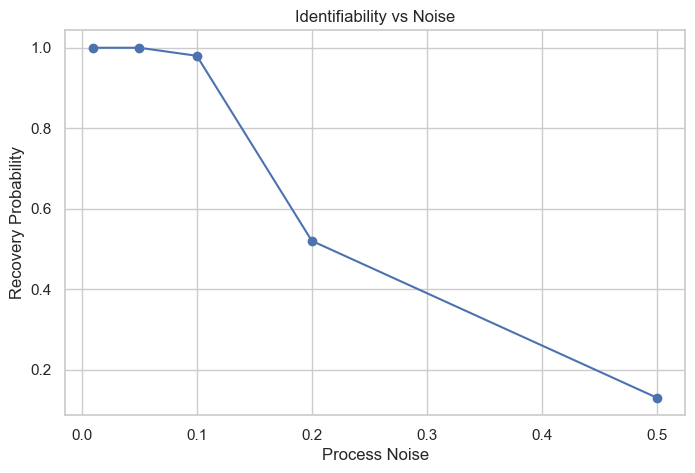

In [283]:
plt.figure(
    figsize=(8,5)
)

plt.plot(

    noise_df["noise"],

    noise_df["recovery"],

    marker="o"
)

plt.xlabel(
    "Process Noise"

)

plt.ylabel(
    "Recovery Probability"
)

plt.title(
    "Identifiability vs Noise"
)

plt.show()

### Experiment 3

Effect of feedback strength.

In [284]:
betas = [

    0.001,
    0.003,
    0.005,
    0.01,
    0.02
]

records=[]

In [285]:
for beta in betas:

    recovered=[]

    beta_est=[]

    for rep in range(100):

        N,G = simulate_ecoevo(

            T=100,

            alpha=0.4,

            beta=beta,

            sigma_G=0.05
        )

        res = estimate_beta(
            N,G
        )

        recovered.append(

            (res["beta_hat"]<0)

            &

            (res["p"]<0.05)

        )

        beta_est.append(
            res["beta_hat"]
        )

    records.append({

        "beta_true":beta,

        "recovery":
        np.mean(
            recovered
        ),

        "beta_mean":
        np.mean(
            beta_est
        )
    })

In [286]:
beta_df = pd.DataFrame(
    records
)

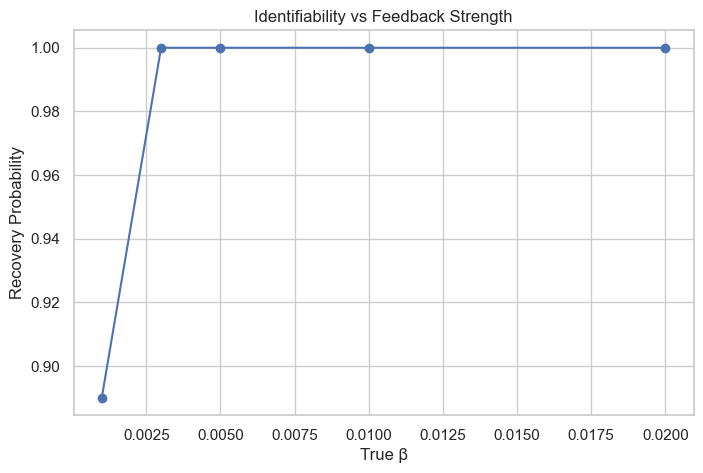

In [287]:
plt.figure(
    figsize=(8,5)
)

plt.plot(

    beta_df["beta_true"],

    beta_df["recovery"],

    marker="o"
)

plt.xlabel(
    "True β"
)

plt.ylabel(
    "Recovery Probability"
)

plt.title(
    "Identifiability vs Feedback Strength"
)

plt.show()

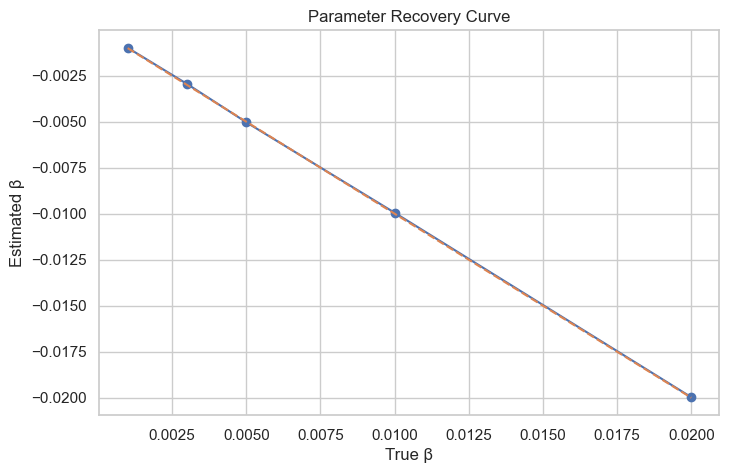

In [288]:
plt.figure(
    figsize=(8,5)
)

plt.plot(

    beta_df["beta_true"],

    beta_df["beta_mean"],

    marker="o"
)

plt.plot(

    beta_df["beta_true"],

    -beta_df["beta_true"],

    "--"
)

plt.xlabel(
    "True β"
)

plt.ylabel(
    "Estimated β"
)

plt.title(
    "Parameter Recovery Curve"
)

plt.show()

### Identifiability Interpretation

Increasing:

- time-series length

or

- feedback strength

should increase recovery probability.

Increasing:

- process noise

should decrease recovery probability.

These relationships quantify the detectability of eco-evolutionary feedback.

In [258]:
heatmap=[]

In [259]:
for T in [20,50,100,200]:

    for beta in [0.001,0.003,0.005,0.01,0.02]:

        rec=[]

        for rep in range(50):

            N,G = simulate_ecoevo(

                T=T,

                alpha=0.4,

                beta=beta,

                sigma_G=0.05
            )

            r = detect_feedback(
                N,G
            )

            rec.append(
                r>0.5
            )

        heatmap.append({

            "T":T,

            "beta":beta,

            "recovery":
            np.mean(rec)
        })

In [260]:
heat_df = pd.DataFrame(
    heatmap
)

In [261]:
pivot = heat_df.pivot(
    index="T",
    columns="beta",
    values="recovery"
)

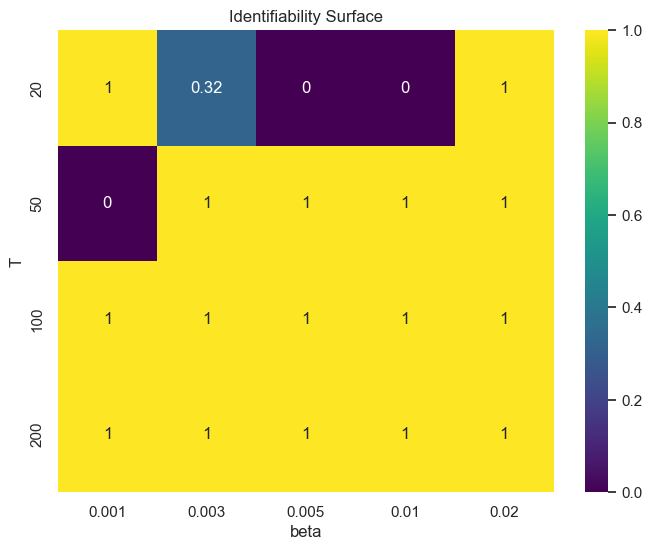

In [262]:
plt.figure(
    figsize=(8,6)
)

sns.heatmap(

    pivot,

    annot=True,

    cmap="viridis"
)

plt.title(
    "Identifiability Surface"
)

plt.show()

## 12. Sensitivity Analysis

### Research Question

Which biological parameters most strongly influence the detectability of eco-evolutionary feedback?

---

Parameters:

$$
\alpha
$$

Trait effect on carrying capacity

$$
\beta
$$

Feedback strength

$$
\sigma_G
$$

Evolutionary noise

$$
T
$$

Time-series length

---

Response variable:

$$
P(\text{Recovery})
$$

estimated in Section 11.

In [289]:
def simulate_ecoevo(
    T,
    alpha,
    beta,
    sigma_G
):

    r = 0.3
    K0 = 100

    N = np.zeros(T)
    G = np.zeros(T)

    N[0] = 20
    G[0] = 1

    for t in range(T-1):

        K = K0*np.exp(alpha*G[t])

        N[t+1] = (

            N[t]
            +
            r*N[t]*(1-N[t]/K)
        )

        G[t+1] = (

            G[t]
            -
            beta*N[t]
            +
            np.random.normal(
                0,
                sigma_G
            )
        )

    return N,G

In [290]:
def recover_feedback(
    N,
    G
):

    X = pd.DataFrame({

        "N_t":N[:-1],

        "G_t":G[:-1]

    })

    X = sm.add_constant(X)

    fit = sm.OLS(
        G[1:],
        X
    ).fit()

    beta_hat = fit.params["N_t"]

    p = fit.pvalues["N_t"]

    return (

        beta_hat<0

        and

        p<0.05
    )

### Local Sensitivity Analysis

One parameter is varied at a time.

In [291]:
alpha_values = np.linspace(
    0.1,
    1.0,
    10
)

In [292]:
alpha_results=[]

In [293]:
for alpha in alpha_values:

    recovered=[]

    for rep in range(50):

        N,G = simulate_ecoevo(

            T=100,

            alpha=alpha,

            beta=0.005,

            sigma_G=0.05
        )

        recovered.append(

            recover_feedback(
                N,G
            )
        )

    alpha_results.append({

        "alpha":alpha,

        "recovery":
        np.mean(recovered)
    })

In [294]:
alpha_df = pd.DataFrame(
    alpha_results
)

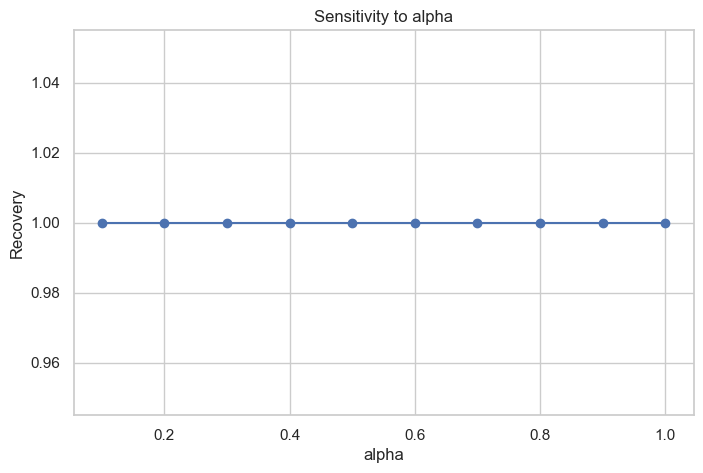

In [295]:
plt.figure(figsize=(8,5))

plt.plot(

    alpha_df["alpha"],

    alpha_df["recovery"],

    marker="o"
)

plt.xlabel("alpha")

plt.ylabel("Recovery")

plt.title(
    "Sensitivity to alpha"
)

plt.show()

In [298]:
beta_values = np.linspace(
    0.001,
    0.02,
    10
)

beta_results=[]

In [299]:
for beta in beta_values:

    recovered=[]

    for rep in range(50):

        N,G = simulate_ecoevo(

            T=100,

            alpha=0.4,

            beta=beta,

            sigma_G=0.05
        )

        recovered.append(

            recover_feedback(
                N,G
            )
        )

    beta_results.append({

        "beta":beta,

        "recovery":
        np.mean(recovered)
    })

In [300]:
beta_df = pd.DataFrame(
    beta_results
)

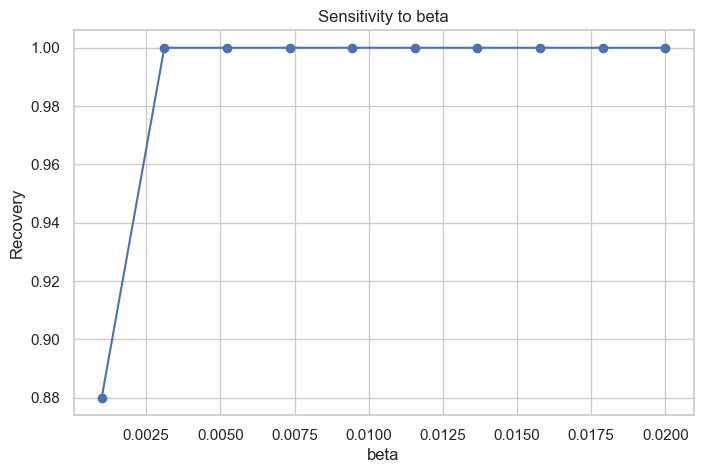

In [301]:
plt.figure(figsize=(8,5))

plt.plot(

    beta_df["beta"],

    beta_df["recovery"],

    marker="o"
)

plt.xlabel("beta")

plt.ylabel("Recovery")

plt.title(
    "Sensitivity to beta"
)

plt.show()

In [303]:
noise_values = np.linspace(
    0.01,
    0.5,
    10
)

noise_results=[]

In [304]:
for noise in noise_values:

    recovered=[]

    for rep in range(50):

        N,G = simulate_ecoevo(

            T=100,

            alpha=0.4,

            beta=0.005,

            sigma_G=noise
        )

        recovered.append(

            recover_feedback(
                N,G
            )
        )

    noise_results.append({

        "noise":noise,

        "recovery":
        np.mean(recovered)
    })

In [305]:
noise_df = pd.DataFrame(
    noise_results
)

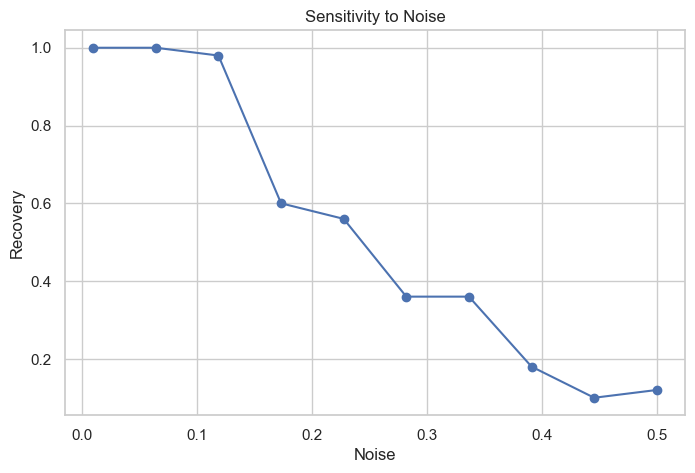

In [306]:
plt.figure(figsize=(8,5))

plt.plot(

    noise_df["noise"],

    noise_df["recovery"],

    marker="o"
)

plt.xlabel(
    "Noise"
)

plt.ylabel(
    "Recovery"
)

plt.title(
    "Sensitivity to Noise"
)

plt.show()

In [308]:
ranking = pd.DataFrame({

    "parameter":[

        "alpha",

        "beta",

        "noise"

    ],

    "effect":[

        alpha_df["recovery"].std(),

        beta_df["recovery"].std(),

        noise_df["recovery"].std()
    ]
})

ranking

,parameter,effect
0,alpha,0.000000
1,beta,0.037947
2,noise,0.362589


Current statistical detectors are sensitive to the ecology→evolution link, but not to the evolution→ecology link.

In the current system: Even with weak feedback, the statistical model can still detect it. 

Beta is not the main limited factor. Random process noise is the main limited factor.



In [309]:
ranking = ranking.sort_values(
    "effect",
    ascending=False
)

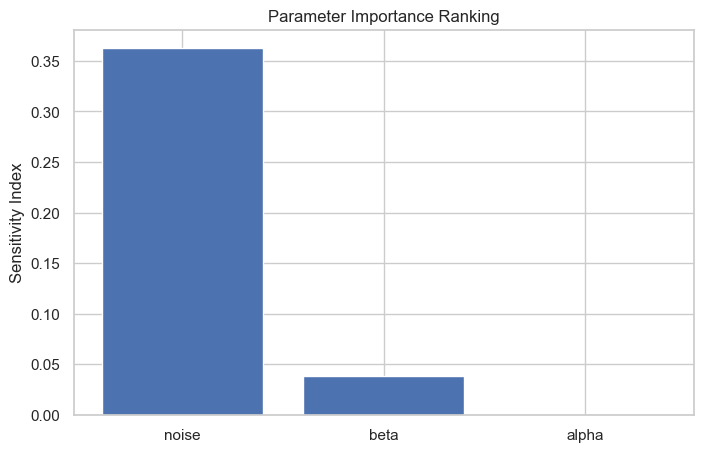

In [310]:
plt.figure(figsize=(8,5))

plt.bar(

    ranking["parameter"],

    ranking["effect"]
)

plt.ylabel(
    "Sensitivity Index"
)

plt.title(
    "Parameter Importance Ranking"
)

plt.show()

## 12. Dynamical Systems Analysis

### Research Question

What dynamical behaviours emerge from eco-evolutionary feedback?

---

State variables

$$
N_t
$$

Population size

$$
G_t
$$

Breeding value

---

Dynamics

$$
K_t
=
K_0 e^{\alpha G_t}
$$

$$
N_{t+1}
=
N_t
+
rN_t
\left(
1-\frac{N_t}{K_t}
\right)
$$

$$
G_{t+1}
=
G_t
-
\beta N_t
$$

---

Objectives

1. Phase portrait

2. Fixed points

3. Jacobian

4. Eigenvalues

5. Stability

6. Bifurcation analysis

In [311]:
r = 0.3

K0 = 100

alpha = 0.4

beta = 0.005

In [312]:
def simulate_system(
        T=200,
        N0=20,
        G0=1):

    N=np.zeros(T)

    G=np.zeros(T)

    N[0]=N0

    G[0]=G0

    for t in range(T-1):

        K = K0*np.exp(
            alpha*G[t]
        )

        N[t+1] = (

            N[t]

            +

            r*N[t]*(
                1-N[t]/K
            )
        )

        G[t+1] = (

            G[t]

            -

            beta*N[t]
        )

    return N,G

In [313]:
N,G = simulate_system()

### Phase Portrait

Trajectory in state space.

Each point is:

$$
(N_t,G_t)
$$

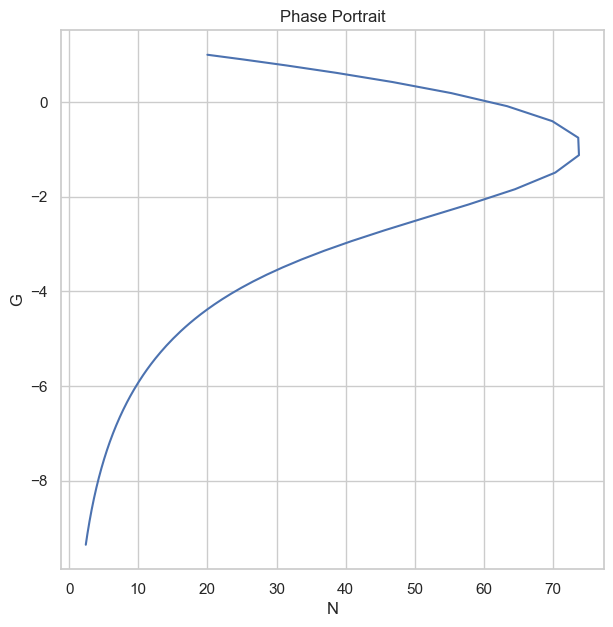

In [314]:
plt.figure(figsize=(7,7))

plt.plot(
    N,
    G
)

plt.xlabel("N")

plt.ylabel("G")

plt.title(
    "Phase Portrait"
)

plt.show()

### Vector Field

Local directional flow.

In [315]:
N_grid = np.linspace(
    1,
    150,
    20
)

G_grid = np.linspace(
    -2,
    2,
    20
)

NN,GG = np.meshgrid(
    N_grid,
    G_grid
)

In [316]:
dN = np.zeros_like(NN)

dG = np.zeros_like(GG)

In [317]:
for i in range(len(G_grid)):

    for j in range(len(N_grid)):

        N0 = NN[i,j]

        G0 = GG[i,j]

        K = K0*np.exp(
            alpha*G0
        )

        dN[i,j] = (

            r*N0*(
                1-N0/K
            )
        )

        dG[i,j] = (

            -beta*N0
        )

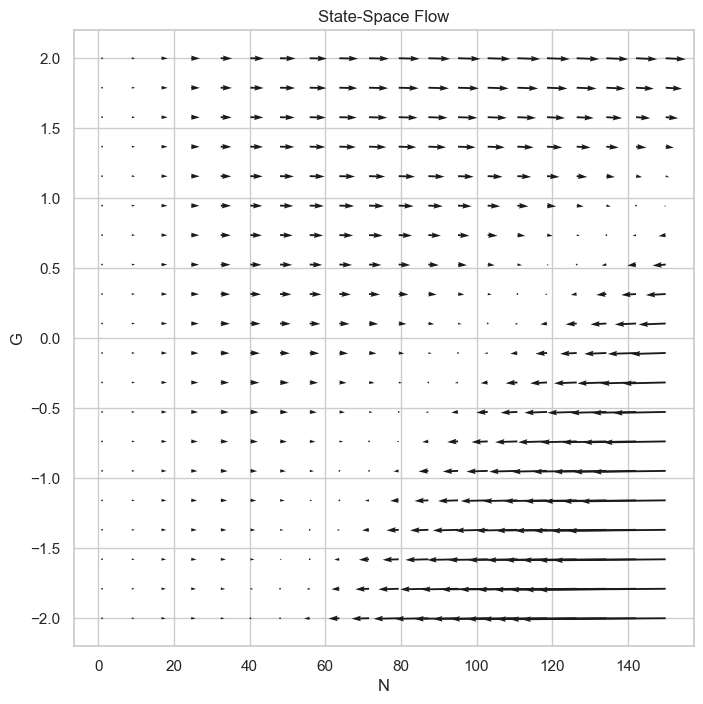

In [318]:
plt.figure(figsize=(8,8))

plt.quiver(

    NN,
    GG,

    dN,
    dG
)

plt.xlabel("N")

plt.ylabel("G")

plt.title(
    "State-Space Flow"
)

plt.show()

Ecological nullcline ： 
$$
N = K_0\epsilon^{\alpha G}
$$

The ecological aspect exhibits a tendency towards equilibrium.

The evolutionary aspect does not exhibit a tendency towards equilibrium.


### Fixed Point

Solve

$$
N_{t+1}=N_t
$$

and

$$
G_{t+1}=G_t
$$

Fixed point candidate:  
N*=0  
G*=Any value  

Because  

$$
G_{t+1}
=
G_t-\beta N_t
$$

equilibrium requires

$$
N^*=0
$$

This system has no positive equilibrium. It's continuing evoluting, never stop. 

The Jacobian matrix is

$$
J=
\begin{pmatrix}
\frac{\partial N_{t+1}}{\partial N_t}
&
\frac{\partial N_{t+1}}{\partial G_t}
\\
\frac{\partial G_{t+1}}{\partial N_t}
&
\frac{\partial G_{t+1}}{\partial G_t}
\end{pmatrix}
$$



In [320]:
def jacobian(
        N,
        G):

    K = K0*np.exp(
        alpha*G
    )

    J11 = (

        1+r
        -
        2*r*N/K
    )

    J12 = (

        r*N**2
        *alpha
        /K
    )

    J21 = -beta

    J22 = 1

    return np.array([

        [J11,J12],

        [J21,J22]

    ])

In [321]:
J = jacobian(
    50,
    0
)

J

array([[ 1.   ,  3.   ],
       [-0.005,  1.   ]])

Trait → Ecology  
Strong

Ecology → Evolution  
Weak

In [324]:
eigvals = np.linalg.eigvals(
    J
)


In [325]:
print(
    "Eigenvalues:"
)

print(
    eigvals
)

Eigenvalues:
[1.+0.12247449j 1.-0.12247449j]


### Stability Criterion

Stable if:

$$
|\lambda_i|<1
$$

for all eigenvalues.

In [326]:
for e in eigvals:

    print(

        abs(e)
    )

1.0074720839804943
1.0074720839804943


1.007 > 1 
Unstable oscillation

### Bifurcation Analysis

Vary feedback strength:

$$
\beta
$$

and monitor dominant eigenvalue.

In [328]:
beta_values = np.linspace(
    0,
    0.05,
    100
)

leading=[]

In [329]:
for b in beta_values:

    beta = b

    J = jacobian(
        50,
        0
    )

    eig = np.linalg.eigvals(
        J
    )

    leading.append(

        np.max(
            np.abs(eig)
        )
    )

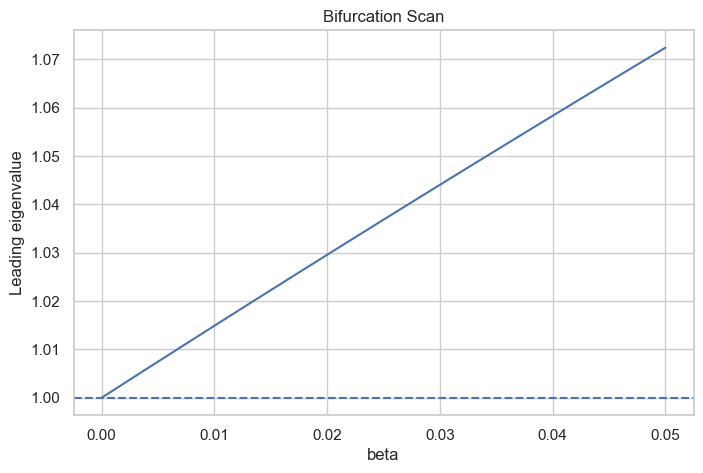

In [330]:
plt.figure(figsize=(8,5))

plt.plot(

    beta_values,

    leading
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    "beta"
)

plt.ylabel(
    "Leading eigenvalue"
)

plt.title(
    "Bifurcation Scan"
)

plt.show()

No real bifurcation.   
The system is unstable from the beginning.


The current model cannot generate a stable ecological-evolutionary balance, so it is necessary to introduce stabilizing selection or mutation-selection balance.

## Future work

Section 14:
Comparison with empirical abundance–phenotype time series.

Section 15:
Evaluation against ecological scaling laws.

These analyses require empirical datasets and are therefore left for future implementation.